# Анализ лояльности пользователей Яндекс Афиши
- Автор: Жукова Наталья
- Дата: 20.03.2026

### Содержание проекта

- [1. Загрузка данных.](#1)
 - [1.1 Подготовка SQL- запроса и подключение к БД](#1.1)
 - [1.2 Знакомство с данными](#1.2)
- [2. Предобработка данных.](#2)
 - [2.1. Оптимизируем типы данные](#2.1)
 - [2.2. Проверяем наличие пропусков в данных](#2.2)
 - [2.3. Явные и неявные дубликаты в данных](#2.3)
- [3. Создание профиля пользователя.](#3)
 - [3.1. Строим профиль пользователя](#3.1)
- [4. Исследовательский анализ данных](#4)
  - [4.1 Исследование признаков первого заказа и их связи с возвращением на платформу](#4.1)
    - [4.1.1 Изучим распределение пользователей по признакам.](#4.1.1)
    - [4.1.2 Анализ возвратов пользователей](#4.1.2)
    - [4.1.3 Проверим продуктовые гипотезы](#4.1.3)
  - [4.2 Исследование поведения пользователей через показатели выручки и состава заказа](#4.2)
    - [4.2.1 Проследим связь между средней выручкой сервиса с заказа и повторными заказами](#4.2.1)
    - [4.2.2 Сравниe распределения по средней выручке с заказа в двух группах пользователей](#4.2.2)
    - [4.2.3  Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки ](#4.2.3)
 - [4.3 Исследование временных характеристик первого заказа и их влияния на повторные покупки](#4.3)
   - [4.3.1 Анализ, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей](#4.3.1)
   - [4.3.2  Анализ, как средний интервал между заказами влияет на удержание клиентов.](#4.3.2)
 - [4.4  Корреляционный анализ количества покупок и признаков пользователя](#4.4)
   - [4.4.1 Корреляционный анализ.](#4.4.1) 
- [5. Общий вывод и рекомендации.](#5)

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка <a id='1'></a>

---
<a id='1.1'></a>
**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---



In [ ]:
try:
    from dotenv import load_dotenv
except:
    !pip install dotenv
    from dotenv import load_dotenv
    
import os, getpass

load_dotenv()

In [ ]:
db_config = {
    'user': os.getenv('PR_USER'),
    'pwd': os.getenv('PWD'),
    'host': os.getenv('HOST'),
    'port': os.getenv('PORT'),
    'db': os.getenv('DB')
}

In [ ]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

создаем соединение

In [ ]:
engine = create_engine(connection_string)

Формируем SQL-запрос и передаем его в датафрейм, подключаемся к БД

In [112]:
query = '''
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk  AS order_dt,
    p.created_ts_msk  AS order_ts,
    p.currency_code ,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (created_dt_msk - 
            LAG (created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk))) AS days_since_prev,
    e.event_id,
    e.event_name_code AS event_name,
    p.service_name,  
    e.event_type_main,
    c.city_name,
    r.region_name 
FROM afisha.purchases p 
  JOIN afisha.events e USING (event_id)
  JOIN afisha.city c ON (e.city_id = c.city_id)
  JOIN afisha.regions r ON (r.region_id = c.region_id)
WHERE p.device_type_canonical IN ('mobile', 'desktop') and
      e.event_type_main <> 'фильм'
ORDER BY p.user_id, p.created_dt_msk
'''

In [113]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе. <a id='1.2'></a>

---

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

Оценим насколько корректно загрузились данные

In [115]:
df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,city_name,region_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Глиногорск,Каменевский регион
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Глиногорск,Каменевский регион
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Глиногорск,Каменевский регион
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Озёрск,Североярская область
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Родниковецк,Озернинский край


**Данные загрузились корректно.** 
- датасет содержит 15 колонок и около 29000 записей.
- датасет имеет размер около 33 МБ
- данные соответствуют описанию
- наименования стобцов имеют единый вид написания
- типы данных используются корректные
- имеются пропуски в столбцу days_since_prev, но это связано с тем, что для первой покупки пользователя расчитать кол-во дней от предыдущей нет возвозможности.   

Тем не менее типы данных в некоторых стобцах стоит преобразовать и нормализовать. 
- Тип object привести к типу string. 
- оплату в тенге перевести в рубли
- service_name, city_name, region_name привести к нижнему регистру

---

###  2. Предобработка данных <a id='2'></a>

Выполните все стандартные действия по предобработке данных:

---
<a id='2.1'></a>
**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---

Выгружаем информацию о курсе казахского тенге по отношению к рублю за 2024 г.

In [116]:
curs_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [117]:
curs_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Данные должны содержать информацию за 2024 г. В году обычно 365 дней, 2024 был високосный, значит в нем 366 дней. Записей в датафрейме 357. Значит скорее всего данные за не полный год. Перепроверим это.

In [118]:
curs_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Информация есть начиная с 10-го числа. Нужно перепроверить еще раз, за какой период отсутствуют данные. Только за первые 9 дней года или же есть нехватка данных о курсе за другие даты? 

In [119]:
#преобразуем столбец даты в тип даты
curs_tenge['data'] = pd.to_datetime(curs_tenge['data'])
# 
curs_tenge.dtypes

data       datetime64[ns]
nominal             int64
curs              float64
cdx                object
dtype: object

In [120]:
#сортируем данные по дате
date_sort = curs_tenge.sort_values('data', ascending=True)
date_sort

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


В отсортированных данных видим, что они действительно начинаются только с 10 января. Значит 366-9 = 357 дней - это кол-во данных, которые есть в датафрейме.

На всякий случай еще одна дополнительная проверка. Выбираем максимальное и минимальное значение даты.

In [121]:
# Для одного столбца
min_date = curs_tenge['data'].min()
max_date = curs_tenge['data'].max()
print(min_date)
print(max_date)

2024-01-10 00:00:00
2024-12-31 00:00:00


Информация подтвердилась. Данные о курсе валют отсутствуют только за первые 9 дней года. В БД, кототую нужно будет проанализтровать данные охватывают весь летний период и два месяца осени 2024 года, поэтому отсутствие нескольких записей в начале года никак не повлияет на дальнейший анализ. 

Напишем функцию для пересчета курса. Данные поместим в отдельный столбец: revenue_rub

In [122]:
def convert_tenge(df_main, df_curs):
    
    df_result = df_main.copy()
    df_result['revenue_rub'] = df_result['revenue']  # по умолчанию
    
    # Подготавливаем df с курсом для объединения с БД 
    curs_tenge_new = curs_tenge.copy()
    curs_tenge_new['curs_n'] = curs_tenge_new ['curs'] / curs_tenge_new['nominal']
    curs_tenge_new = curs_tenge_new[['data', 'curs_n']]
    curs_tenge_new = curs_tenge_new.rename(columns={'data': 'order_dt'})

    #объединяем таблицы по дате
    df_result = df_result.merge(curs_tenge_new, on='order_dt', how='left')
    
    # задаем маску валюты
    mask = df_result['currency_code'] == 'kzt'
    # Конвертируем для валюты
    df_result.loc[mask, 'revenue_rub'] = round(df_result.loc[mask, 'revenue'] * 
                                               df_result.loc[mask, 'curs_n'], 2
                                               )   
     # Для отладки
    print(f"Сконвертировано {mask.sum()} строк с тенге")
    
    return df_result

In [123]:
# Использование
df_final = convert_tenge(df, curs_tenge)

Сконвертировано 5069 строк с тенге


---

**Задача 2.2:** <a id='2.2'></a>

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

проверим на пропуски и дубликаты

In [124]:
df_final.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
city_name                    0
region_name                  0
revenue_rub                  0
curs_n                       0
dtype: int64

Пропусков в основных данных нет. Пропуски в столбцe days_since_prev допустимы и объяснимы.

In [125]:
# Проверяем полные дубликаты в датафрейме 
df_final.duplicated().sum()

0

In [126]:
# Проверяем неявные дубликаты в датафрейме 
df_final.duplicated(subset='order_id').sum()

0

Явных и неявных дубликатов в дайтафрейме нет.

Преобразуем некотoрые типы данных

In [127]:
# Приводим тип данных 
cols_to_convert = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main', 'city_name','region_name']
df_final[cols_to_convert] = df_final[cols_to_convert].astype('string', errors='ignore')
df_final['days_since_prev'] = df_final['days_since_prev'].astype('Int64', errors='ignore')

In [128]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  string        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  string        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  Int64         
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  string        
 12  event_type_main        290611 non-null  stri

Посмотрим уникальные значения в категориальных столбцах

In [129]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['device_type_canonical', 'service_name', 'event_type_main']:
    print(f'Уникальные значения в столбце {column}:')
    print(df_final[column].sort_values().unique())
    print()

Уникальные значения в столбце device_type_canonical:
<StringArray>
['desktop', 'mobile']
Length: 2, dtype: string

Уникальные значения в столбце service_name:
<StringArray>
[         'Crazy ticket!',            'Show_ticket',      'Билет по телефону',
     'Билеты без проблем',     'Билеты в интернете',          'Билеты в руки',
            'Быстробилет',         'Быстрый кассир',         'Весь в билетах',
              'Восьмёрка',                'Вперёд!',         'Выступления.ру',
 'Городской дом культуры',           'Дом культуры',                'Дырокол',
            'За билетом!',               'Зе Бест!',             'КарандашРУ',
             'Кино билет',           'Край билетов',                 'Лимоны',
            'Лови билет!',          'Лучшие билеты',               'Мир касс',
              'Мой билет',                'Облачко',              'Прачечная',
           'Радио ticket',                 'Реестр',               'Росбилет',
            'Тебе билет!',           

ошибок и неявных дубликатов в категориальных столбцах нет

Нормализуем значения в столбцах город и регион, а также в наименовании билетного оператора

In [130]:
# удалим лишние пробелы в наименованиях и приведем к нижнему регистру
for column in ['service_name', 'city_name', 'region_name']:
     df_final[column] = df_final[column].str.strip().str.lower()

In [131]:
df_final.head(3)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,city_name,region_name,revenue_rub,curs_n
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,<NA>,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,край билетов,театр,глиногорск,каменевский регион,1521.94,0.186972
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,<NA>,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,мой билет,выставки,глиногорск,каменевский регион,289.45,0.183419
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,за билетом!,другое,глиногорск,каменевский регион,1258.57,0.196475


#### Проведем анализ выручки с заказа

In [132]:
# Анализируем основные числовые показатели
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ВЫРУЧКИ С ЗАКАЗА")
# Основные статистики
df_final['revenue_rub'].describe()

СТАТИСТИЧЕСКИЙ АНАЛИЗ ВЫРУЧКИ С ЗАКАЗА


count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Очень большой разброс между минимумом и максимумом значений, даже есть отрицательные значения. Большое значение стандартного отклонения - 875, среднее (555)и медиана (351) различаются почти в 1,5 раза. Посмотрим на графике выбросы.

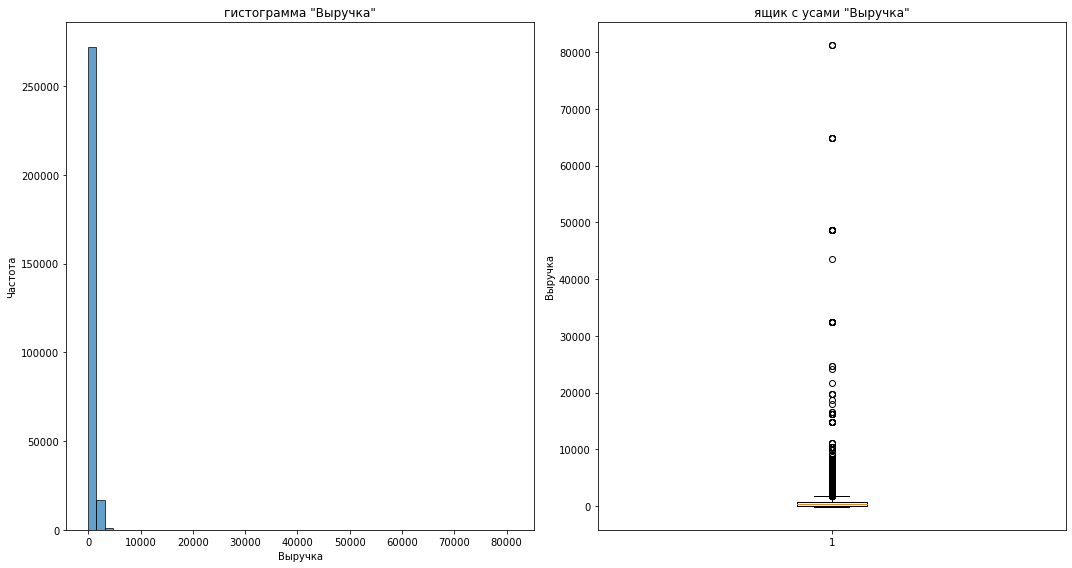

In [133]:
# Создаем графики для визуального анализа
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

ax = axes.flatten()

# Гистограмма
ax[0].hist(df_final['revenue_rub'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax[0].set_title(f'гистограмма "Выручка"')
ax[0].set_xlabel('Выручка')
ax[0].set_ylabel('Частота')
    
# Ящик с усами (boxplot)
ax[1].boxplot(df_final['revenue_rub'].dropna())
ax[1].set_title(f'ящик с усами "Выручка"')
ax[1].set_ylabel('Выручка')
        
plt.tight_layout()
plt.show()

На гистограмме видим сильную правостороннюю ассиметрию; ящик с усами показывает большое количество выбросов в данных. 

Посмотрим на ящик с усами без учета выбросов.

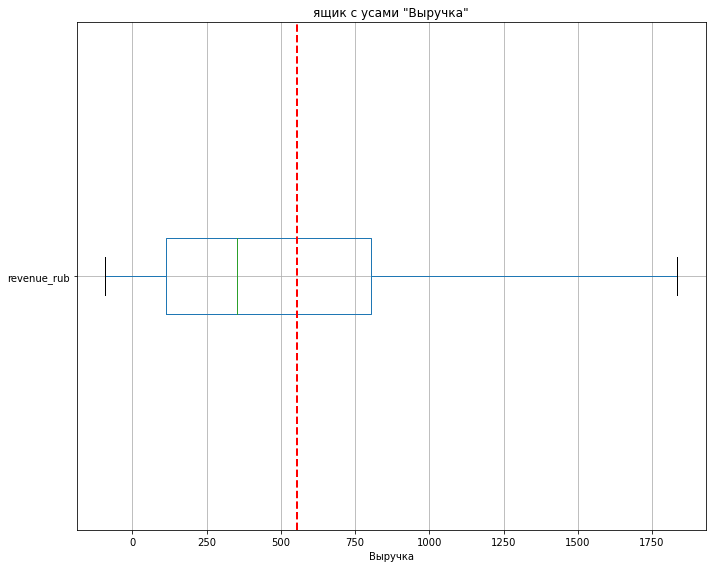

In [134]:
# Ящик с усами (boxplot)
bx = df_final.boxplot(column = 'revenue_rub',
                      showfliers=False,
                      vert = False,
                      figsize=(10, 8))
bx.set_title(f'ящик с усами "Выручка"')
bx.set_xlabel('Выручка')

# Добавляем линию среднего значения
mean_value = df_final['revenue_rub'].mean()
plt.axvline(x=mean_value, color='red', linestyle='--', linewidth=2)
        
plt.tight_layout()
plt.show()

Нижняя граница размаха уходит в минус. Максмальное значение размаха примерно 1860. Как отмечалос ранее среднее и медиана отличаются примернов 1,5 раза. Только четверть покупок превышает 800р, остальные покупки ниже 351р.

Посмотрим суммы более крупных покупок. Для этого посмотрим статистические показатели с учетом 95-го и 99-го процентилей

In [135]:
print(f"95-й прецентиль: {df_final['revenue_rub'].quantile(0.95)}")
print(f"99-й прецентиль: {df_final['revenue_rub'].quantile(0.99)}")      

95-й прецентиль: 1630.65
99-й прецентиль: 2628.42


 - Основной объем покупок (99% случаев) находится в диапазоне от 0 до 2600 рублей
 - Сегмент клиентов с покупками от 2600 до 81000 рублей (топ-1%) требует отдельного анализа.(скорее всего это спекулянты, которые выкупают билеты для дальнейшей перепродажи, возможно среди них часть организации, которые могут покупать билеты для своих сотрудников)

**Для дальнейшего анализа отфильтруем датасет по 99-му прецентилю и построим гистограмму**

ДЕТАЛЬНЫЙ АНАЛИЗ ПОЛЯ ВЫРУЧКИ (revenue_rub)

--- До фильтрации ---
Всего записей: 290611
Среднее: 555.57
Медиана: 351.14
Максимум: 81,174.54
Минимум: -90.76

Отрицательные значения: 381 (0.13%)
Нулевые значения: 5526 (1.90%)

Перцентили:
  95-й: 1,630.65
  99-й: 2,628.42

Значения выше 99 перцентиля:
  Количество: 2825 (0.97%)
  Минимальное среди выбросов: 2,628.63
  Максимальное среди выбросов: 81,174.54

--- После фильтрации по 99 перцентилю ---
Всего записей: 287786
Удалено записей: 2825 (0.97%)
Среднее: 518.03
Медиана: 343.85
Максимум: 2,628.42


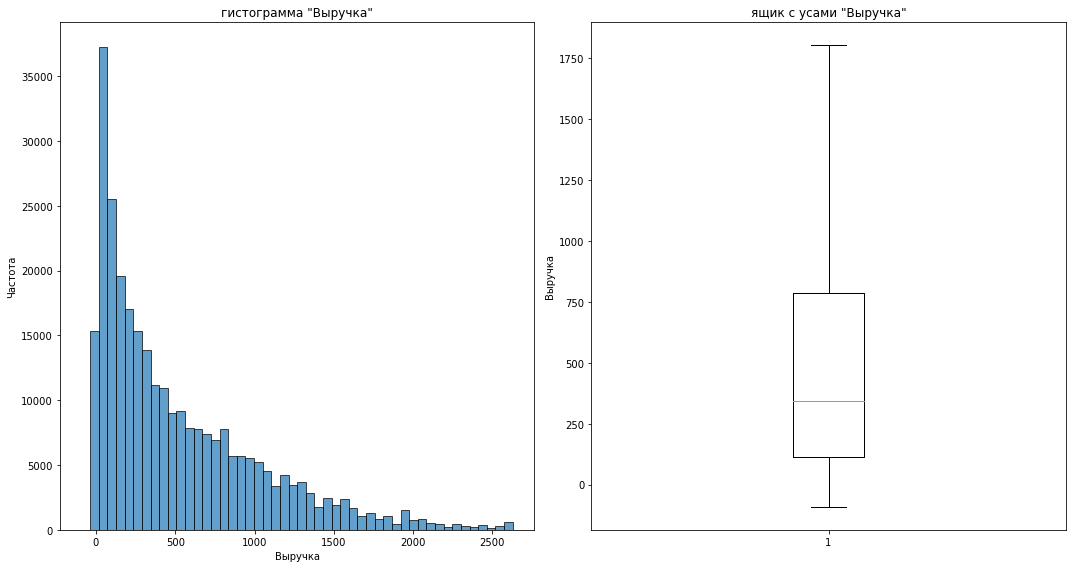

In [136]:
# Детальный анализ revenue_rub
col = 'revenue_rub'
if col in df_final.columns:
    print(f"ДЕТАЛЬНЫЙ АНАЛИЗ ПОЛЯ ВЫРУЧКИ ({col})")
    
    # Статистика до фильтрации
    print(f"\n--- До фильтрации ---")
    print(f"Всего записей: {len(df_final)}")
    print(f"Среднее: {df_final[col].mean():,.2f}")
    print(f"Медиана: {df_final[col].median():,.2f}")
    print(f"Максимум: {df_final[col].max():,.2f}")
    print(f"Минимум: {df_final[col].min():,.2f}")
    
    # Проверка на отрицательные значения
    negative_count = (df_final[col] < 0).sum()
    if negative_count > 0:
        print(f"\nОтрицательные значения: {negative_count} ({negative_count/len(df_final)*100:.2f}%)")
    
    # Проверка на нулевые значения
    zero_count = (df_final[col] == 0).sum()
    if zero_count > 0:
        print(f"Нулевые значения: {zero_count} ({zero_count/len(df_final)*100:.2f}%)")
    
    # 99 перцентиль
    p99 = df_final[col].quantile(0.99)
    p95 = df_final[col].quantile(0.95)
   
    print(f"\nПерцентили:")
    print(f"  95-й: {p95:,.2f}")
    print(f"  99-й: {p99:,.2f}")
      
    # Количество значений выше 99 перцентиля
    above_p99 = df_final[df_final[col] > p99]
    print(f"\nЗначения выше 99 перцентиля:")
    print(f"  Количество: {len(above_p99)} ({len(above_p99)/len(df_final)*100:.2f}%)")
    print(f"  Минимальное среди выбросов: {above_p99[col].min():,.2f}")
    print(f"  Максимальное среди выбросов: {above_p99[col].max():,.2f}")
    
    # Фильтрация по 99 перцентилю
    df_final_fl = df_final[df_final[col] <= p99].copy()
    
    print(f"\n--- После фильтрации по 99 перцентилю ---")
    print(f"Всего записей: {len(df_final_fl)}")
    print(f"Удалено записей: {len(df_final) - len(df_final_fl)} ({(len(df_final) - len(df_final_fl))/len(df_final)*100:.2f}%)")
    print(f"Среднее: {df_final_fl[col].mean():,.2f}")
    print(f"Медиана: {df_final_fl[col].median():,.2f}")
    print(f"Максимум: {df_final_fl[col].max():,.2f}")
    
    # Визуализация после фильтрации
    fig, axes = plt.subplots(1, 2, figsize=(15, 8))
    
    # До фильтрации
    ax = axes.flatten()

    # Гистограмма
    ax[0].hist(df_final_fl['revenue_rub'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax[0].set_title(f'гистограмма "Выручка"')
    ax[0].set_xlabel('Выручка')
    ax[0].set_ylabel('Частота')
    
    # Ящик с усами (boxplot)
    ax[1].boxplot(df_final_fl['revenue_rub'].dropna(), showfliers=False)
    ax[1].set_title(f'ящик с усами "Выручка"')
    ax[1].set_ylabel('Выручка')
    
    plt.tight_layout()
    plt.show()

После фильтрации данных по 99-му прецентилю было исключено 0,97% данных. Гистограмма выручки имеет правоскошеную направденность.

#### Проанализируем распределение количества билетов заказе    

In [137]:
# Анализируем основные числовые показатели
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ КОЛ-ВА БИЛЕТОВ В ЗАКАЗЕ")
# Основные статистики
df_final_fl['tickets_count'].describe()

СТАТИСТИЧЕСКИЙ АНАЛИЗ КОЛ-ВА БИЛЕТОВ В ЗАКАЗЕ


count    287786.000000
mean          2.740495
std           1.163073
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

Как и в случае с выручкой очень большой разброс значений между мин и мах. Скорее всего также имеется большое количество выбросов. Хотя среднее и медиана отличаются незначительно. Посмотрим на графиках.

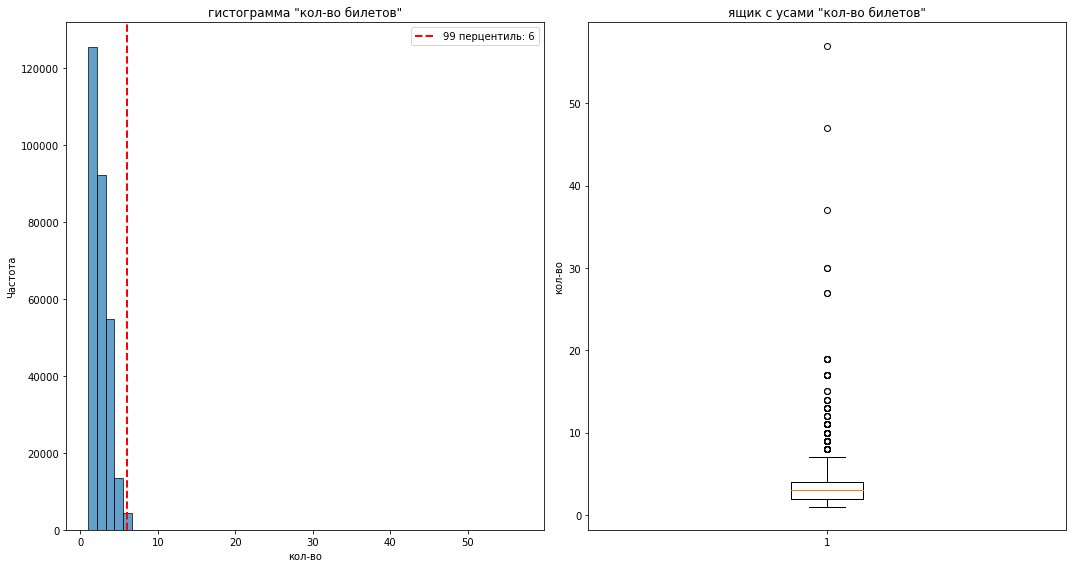

In [138]:
# Создаем графики для визуального анализа
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

ax = axes.flatten()

p99 = df_final['tickets_count'].quantile(0.99)

# Гистограмма
ax[0].hist(df_final['tickets_count'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax[0].axvline(p99, color='red', linestyle='--', linewidth=2, label=f'99 перцентиль: {p99:,.0f}')
ax[0].set_title(f'гистограмма "кол-во билетов"')
ax[0].set_xlabel('кол-во')
ax[0].set_ylabel('Частота')
ax[0].legend()

    
# Ящик с усами (boxplot)
ax[1].boxplot(df_final['tickets_count'].dropna())
ax[1].set_title(f'ящик с усами "кол-во билетов"')
ax[1].set_ylabel('кол-во')
        
plt.tight_layout()
plt.show()

Гистограмма правоскошенная как и гистограмма выручки. Кол-во выбросов, меньше чем в поле выручка, но тем не менее все равно присутствуют. Подсчитаем процент выбросов. 

In [139]:
 # Выбросы для tickets_count (нестандартно большое количество билетов)
p99_tickets = df_final_fl['tickets_count'].quantile(0.99)
large_orders = df_final_fl[df_final_fl['tickets_count'] > p99_tickets]

print(f"  Крупные заказы (> 99 прецентиля):")
print(f"  Порог: {p99_tickets:.0f} билетов")
print(f"  Количество заказов: {len(large_orders)} ({len(large_orders)/len(df_final)*100:.2f}%)")
print(f"  Максимальное количество билетов: {large_orders['tickets_count'].max():.0f}") 

  Крупные заказы (> 99 прецентиля):
  Порог: 6 билетов
  Количество заказов: 180 (0.06%)
  Максимальное количество билетов: 57


Посмотрим более детальное распределение количества билетов в заказе.

In [140]:
# Группировка
df_final_gr = df_final_fl.groupby('tickets_count')['order_id'].agg('count').reset_index()

# Переименование через rename
df_final_gr = df_final_gr.rename(columns={
    'tickets_count': 'Количество_билетов',
    'order_id': 'Число_заказов'
})
# Добавляем проценты
df_final_gr['Процент_заказов'] = (df_final_gr['Число_заказов'] / df_final_gr['Число_заказов'].sum() * 100).round(2)

#сортируес по числу заказов
df_final_gr = df_final_gr.sort_values('Число_заказов', ascending=False)

# Сбрасываем индекс после сортировки для красоты
df_final_gr = df_final_gr.reset_index(drop=True)

df_final_gr.head(6)

,Количество_билетов,Число_заказов,Процент_заказов
0,3,91724,31.87
1,2,83649,29.07
2,4,53642,18.64
3,1,41788,14.52
4,5,12858,4.47
5,6,3945,1.37


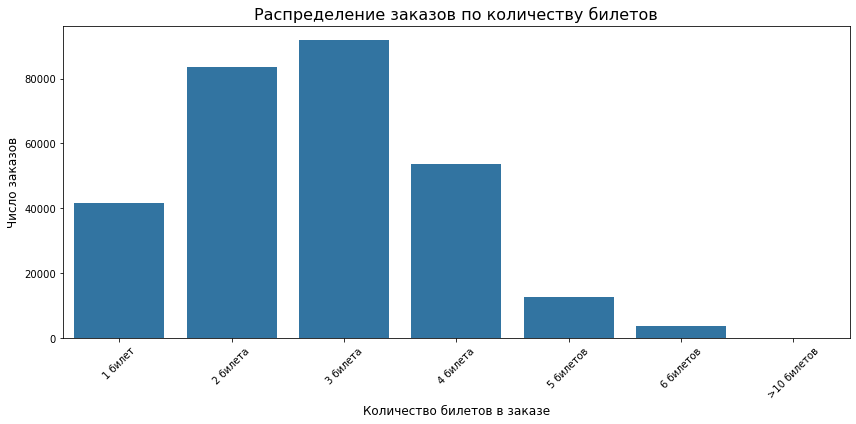

Распределение по категориям:
Категория
1 билет       41788
2 билета      83649
3 билета      91724
4 билета      53642
5 билетов     12858
6 билетов      3945
>6 билетов      180
Name: Число_заказов, dtype: int64


In [141]:
# Создаем категории для лучшей визуализации
df_final_gr['Категория'] = pd.cut(df_final_gr['Количество_билетов'], 
                                  bins=[0, 1, 2, 3, 4, 5, 6, float('inf')], 
                                  labels=['1 билет', '2 билета', '3 билета', '4 билета', 
                                         '5 билетов', '6 билетов', '>6 билетов'],
                                  right=True)

# Группируем по категориям
df_grouped = df_final_gr.groupby('Категория', observed=True)['Число_заказов'].sum().reset_index()

# Сортируем категории в правильном порядке
category_order = ['1 билет', '2 билета', '3 билета', '4 билета', '5 билетов', '6 билетов', '>10 билетов']
df_grouped['Категория'] = pd.Categorical(df_grouped['Категория'], categories=category_order, ordered=True)
df_grouped = df_grouped.sort_values('Категория')

# Строим график
plt.figure(figsize=(12, 6))
sns.barplot(data=df_grouped, x='Категория', y='Число_заказов')
plt.title('Распределение заказов по количеству билетов', fontsize=16)
plt.xlabel('Количество билетов в заказе', fontsize=12)
plt.ylabel('Число заказов', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Проверяем распределение
print("Распределение по категориям:")
print(df_final_gr.groupby('Категория', observed=True)['Число_заказов'].sum())

Наибольшее число заказов с количеством билетов 3 шт., их 31%; Чаще всего в заказах встречаются от 1-4 билетов. Имеются заказы с большим количеством билетов (мах - 57шт). Заказов с большим количеством билетов всего 180 шт.

 **В ходе предъобработки данных были произведены следующие действия:**
- Данные о выручке сервиса были представлены в российских рублях и казахстанских тенге. Привели выручку к единой валюте — российскому рублю.Создали дополнительное поле в БД и конвертировали данные в соотвествии с курсом тенге.
- Преобразовали типы данных в некоторых столбцах; сократили размерность некоторых числовых столбцов.
- Нормализованы значения в столбцах город и регион, а также в наименовании билетного оператора.
- проверили на пропуски и дубликаты. Дубликаты не обнаружены.Пропуски только в вновь созданном поле days_since_prev, что допустимо.
- создано 2 дополнительных столбца: revenue_rub (конвертация из тенге в рубли) и curs_n (курс тенге к рублю) Всего 17 столбцов.
- данные были отфильтрованы по 99-му прецентилю. Мы избавились таким образом от выбросов в размере 0,97% от общего объема данных

---

### 3. Создание профиля пользователя <a id='3'></a>

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---
<a id='3.1'></a>
**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


**Создадим профиль пользователя**

In [142]:
#df_sorted_date = df_final_fl.sort_values(by=['user_id', 'order_ts'], ascending=True)
# сортируем по дате
df_sorted_date = df_final_fl.sort_values(by= ['order_ts'], ascending=True)

#группируем и агрегируем данные по пользователю
df_user_prof = df_sorted_date.groupby('user_id').agg( 
    first_order_date=('order_ts', 'first'),
    last_order_date=('order_ts', 'last'),
    total_orders=('order_id', 'count'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).round(2).reset_index()

#выбираем данные первого заказа пользователя
first_orders = df_sorted_date.groupby('user_id').first().reset_index()
first_orders_info = first_orders[['user_id', 'device_type_canonical', 
                                  'region_name', 'service_name', 'event_type_main']]
#переименовываем столбцы 
first_orders_info.columns = ['user_id', 'first_device', 'first_region', 
                             'first_service', 'first_event']

# Добавляем информацию о первом заказе к базовой информации
df_user_prof = df_user_prof.merge(first_orders_info, on='user_id', how='left')

# Добавляем бинарные признаки  о кол-ве заказов совершенных пользователем
df_user_prof['is_two'] = (df_user_prof['total_orders'] >= 2).astype(int)
df_user_prof['is_five'] = (df_user_prof['total_orders'] >= 5).astype(int)

In [143]:
df_user_prof.head(3)

,user_id,first_order_date,last_order_date,total_orders,avg_revenue,avg_tickets,avg_days_between,first_device,first_region,first_service,first_event,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.94,4.00,<NA>,mobile,каменевский регион,край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.01,3.00,75.0,mobile,каменевский регион,мой билет,выставки,1,0
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.21,2.67,51.0,mobile,североярская область,лови билет!,другое,1,0


Таким образом мы подготовили датасет, описывающий поведение и профиль каждого пользователя. Он понадобиться нам для дальнейшего анализа

---
<a id='3.2'></a>
**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

**Рассчитаем основные метрики профиля пользователя**

In [144]:
# Расчет метрик
total_users = df_user_prof['user_id'].nunique()
avg_revenue_order = df_user_prof['avg_revenue'].mean()
prc_two = (df_user_prof['is_two'].sum() / total_users * 100)
prc_five = (df_user_prof['is_five'].sum() / total_users * 100)

# Вывод результатов
print("-"*45)
print("ИТОГОВЫЕ МЕТРИКИ:")
print("-"*50)
print(f"Общее число пользователей: {total_users:}")
print(f"Средняя выручка с одного заказа: {avg_revenue_order:.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {prc_two:.2f}%")
print(f"Доля пользователей с 5+ заказами: {prc_five:.2f}%")

---------------------------------------------
ИТОГОВЫЕ МЕТРИКИ:
--------------------------------------------------
Общее число пользователей: 21854
Средняя выручка с одного заказа: 544.40 руб.
Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%


Изучим статистические показатели

In [145]:
# Статистика только по определенным полям
selected_columns = ['total_orders', 'avg_tickets', 'avg_days_between']
stats = df_user_prof[selected_columns].describe().round(2)
# Переименовываем столбцы
stats_renamed = stats.rename(columns={
    'total_orders': 'Всего заказов',
    'avg_tickets': 'Ср. кол-во билетов', 
    'avg_days_between':'Ср. кол-во дней между покупками'
})  
print("-"*75)
print("СТАТИСТИКА ПО ЗАДАННЫМ ПОЛЯМ:")
print("-"*75)
stats_renamed

---------------------------------------------------------------------------
СТАТИСТИКА ПО ЗАДАННЫМ ПОЛЯМ:
---------------------------------------------------------------------------


,Всего заказов,Ср. кол-во билетов,Ср. кол-во дней между покупками
count,21854.00,21854.00,13521.0
mean,13.17,2.74,15.84
std,121.67,0.91,22.3
min,1.00,1.00,0.0
25%,1.00,2.00,1.0
50%,2.00,2.75,8.0
75%,5.00,3.08,20.4
max,10181.00,11.00,148.0


- Данных для анализа достаточно

**Заказы:**
- Сильная асимметрия: среднее (13.2) намного выше медианы (2)
- Eсть покупатели с экстремальным числом билетов в заказе (max = 10181 заказов!)
- 75% пользователей сделали ≤ 5 заказов
- Лояльные пользователи (с 5+ заказами) - 29%
- Доля пользователей с 2+ заказами: 61.71%, больше половины покупателей возвращаются
- Средняя выручка с одного заказа: 544.40 руб. 
 
**Покупка билетов**
- В среднем 2.74 билета на заказ
- Медиана близка к среднему (2.75) - распределение ближе к нормальному
- Большинство покупает 2-3 билета за раз

**Частота покупок**
- 13521 пользователей (61.9%) совершают повторные покупки
- В среднем возвращаются через 2 недели (15.8 дней)
- Медианное время возврата: 8.0 дней
- 25% самых лояльных возвращаются в течение 1 дня

Посмотрим на значения 95-го и 99-го прецентиля

In [146]:
p95 = df_user_prof['total_orders'].quantile(0.95)
p99 = df_user_prof['total_orders'].quantile(0.99)

print(f"95-й прецентиль: {p95:.2f}")
print(f"99-й прецентиль: {p99:.2f}")      

95-й прецентиль: 31.35
99-й прецентиль: 152.00


Подсчитаем % объема данных по 95-му и 99-му прецентилям, чтобы понять по какому прецентилю лучше отфильтровать данные.

In [147]:
large_orders95 = df_user_prof[df_user_prof['total_orders'] > p95]
large_orders99 = df_user_prof[df_user_prof['total_orders'] > p99]

print(f"  Крупные заказы (> 95 прецентиля):")
print(f"  Порог: {p95:.0f} билетов")
print(f"  Количество заказов: {len(large_orders95)} ({len(large_orders95)/len(df_user_prof)*100:.2f}%)")
print(f"  Максимальное количество билетов: {large_orders95['total_orders'].max():.0f}") 
print("-"*75)
print(f"  Крупные заказы (> 99 рецентиля):")
print(f"  Порог: {p99:.0f} билетов")
print(f"  Количество заказов: {len(large_orders99)} ({len(large_orders99)/len(df_user_prof)*100:.2f}%)")
print(f"  Максимальное количество билетов: {large_orders99['total_orders'].max():.0f}") 

  Крупные заказы (> 95 прецентиля):
  Порог: 31 билетов
  Количество заказов: 1093 (5.00%)
  Максимальное количество билетов: 10181
---------------------------------------------------------------------------
  Крупные заказы (> 99 рецентиля):
  Порог: 152 билетов
  Количество заказов: 216 (0.99%)
  Максимальное количество билетов: 10181


Если мы отфильтруем по 95-му прецентилю, то потеряем 5% данных, это достаточно много. Поэтому фильтруем по 99-му, т.к это всего лишь 1%

In [148]:
# Фильтрация по 99 прецентилю
df_user_prof99 = df_user_prof[df_user_prof['total_orders'] <= p99].copy()

In [149]:
# Расчет метрик после фильтрации
total_users = df_user_prof99['user_id'].nunique()
avg_revenue_order = df_user_prof99['avg_revenue'].mean()
prc_two = (df_user_prof99['is_two'].sum() / total_users * 100)
prc_five = (df_user_prof99['is_five'].sum() / total_users * 100)

# Вывод результатов
print("-"*45)
print("ИТОГОВЫЕ МЕТРИКИ:")
print("-"*50)
print(f"Общее число пользователей: {total_users:}")
print(f"Средняя выручка с одного заказа: {avg_revenue_order:.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {prc_two:.2f}%")
print(f"Доля пользователей с 5+ заказами: {prc_five:.2f}%")

# Статистика только по определенным полям
selected_columns = ['total_orders', 'avg_tickets', 'avg_days_between']
stats = df_user_prof99[selected_columns].describe().round(2)
# Переименовываем столбцы
stats_renamed = stats.rename(columns={
    'total_orders': 'Всего заказов',
    'avg_tickets': 'Ср. кол-во билетов', 
    'avg_days_between':'Ср. кол-во дней между покупками'
})  
print("-"*75)
print("СТАТИСТИКА ПО ЗАДАННЫМ ПОЛЯМ:")
print("-"*75)
stats_renamed

---------------------------------------------
ИТОГОВЫЕ МЕТРИКИ:
--------------------------------------------------
Общее число пользователей: 21638
Средняя выручка с одного заказа: 544.71 руб.
Доля пользователей с 2+ заказами: 61.33%
Доля пользователей с 5+ заказами: 28.30%
---------------------------------------------------------------------------
СТАТИСТИКА ПО ЗАДАННЫМ ПОЛЯМ:
---------------------------------------------------------------------------


,Всего заказов,Ср. кол-во билетов,Ср. кол-во дней между покупками
count,21638.00,21638.00,13305.0
mean,6.50,2.74,16.09
std,14.32,0.92,22.39
min,1.00,1.00,0.0
25%,1.00,2.00,1.33
50%,2.00,2.75,8.33
75%,5.00,3.10,20.75
max,152.00,11.00,148.0


После фильтрации характеристики в столбце по общему количеству заказов выравнялись, т.к мы избавились от выбросов и аномалий.

---

### 4. Исследовательский анализ данных <a id='4'></a>

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу <a id='4.1'></a>

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---
<a id='4.1.1'></a>
**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [150]:
#мероприятие
gr_event = df_user_prof99.groupby(['first_event'])['user_id'].count().reset_index()
# устройство
gr_device = df_user_prof99.groupby(['first_device'])['user_id'].count().reset_index()
# регион
gr_region = df_user_prof99.groupby(['first_region'])['user_id'].count().reset_index()
# сервис
gr_service = df_user_prof99.groupby(['first_service'])['user_id'].count().reset_index()

# Добавляем долю
total_users = gr_event['user_id'].sum()
gr_event['user_ev_share'] = (gr_event['user_id'] / total_users * 100).round(2)
gr_device['user_dev_share'] = (gr_device['user_id'] / total_users * 100).round(2)
gr_region['user_reg_share'] = (gr_region['user_id'] / total_users * 100).round(2)
gr_service['user_serv_share'] = (gr_service['user_id'] / total_users * 100).round(2)

# Сортируем
gr_event = gr_event.sort_values('user_id', ascending=False)
gr_device = gr_device.sort_values('user_id', ascending=False)
gr_region = gr_region.sort_values('user_id', ascending=False)
gr_service = gr_service.sort_values('user_id', ascending=False)

# Переименовываем столбцы
gr_event_rm = gr_event.rename(columns={
    'first_event': '1-е мероприятие',
    'user_id': 'кол-во польз.', 
    'user_ev_share':'доля польз.'
})  

gr_device_rm = gr_device.rename(columns={
    'first_device': '1-е устр-во',
    'user_id': 'кол-во польз.', 
    'user_dev_share':'доля польз.'
})  
gr_region_rm = gr_region.rename(columns={
    'first_region': '1-й регион',
    'user_id': 'кол-во польз.', 
    'user_reg_share':'доля польз.'
}) 
gr_service_rm = gr_service.rename(columns={
    'first_service': '1-й сервис',
    'user_id': 'кол-во польз.', 
    'user_serv_share':'доля польз.'}) 


- Данные сгруппированные по типу 1-го мероприятия

In [151]:
gr_event_rm

,1-е мероприятие,кол-во польз.,доля польз.
2,концерты,9560,44.18
1,другое,5426,25.08
5,театр,4239,19.59
4,стендап,1110,5.13
3,спорт,794,3.67
0,выставки,414,1.91
6,ёлки,95,0.44


Визуализируем информацию с помощью столбчатой гистограммы

<Figure size 1080x720 with 0 Axes>

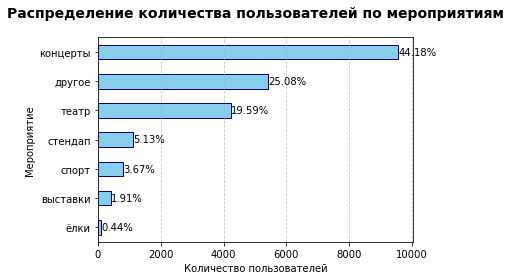

In [152]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

gr_event = gr_event.sort_values('user_id', ascending=True)

gr_event.plot(
    x='first_event',        
    y='user_id',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Количество пользователей')  
plt.ylabel('Мероприятие')                

# Добавляем значения на столбцы
# Добавляем значения на столбцы
for i, (_, row) in enumerate(gr_event.iterrows()):
    plt.text(row['user_id'] + 5, i, f"{row['user_ev_share']:,.2f}%", 
             va='center', fontsize=10)

# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение количества пользователей по мероприятиям', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Выводы:** Самое популярное мероприятие среди пользователей - это концерты (44%), далее театр и другое (около 20%), остальные мероприятия занимают от 2-до 5%. Елки всего 0,44%, т.к это сезонное мероприятие.

- Данные сгруппированные по типу устройства, с которого совершена первая покупка

In [153]:
gr_device_rm

,1-е устр-во,кол-во польз.,доля польз.
1,mobile,17924,82.84
0,desktop,3714,17.16


Визуализируем информацию с помощью круговой диаграммы

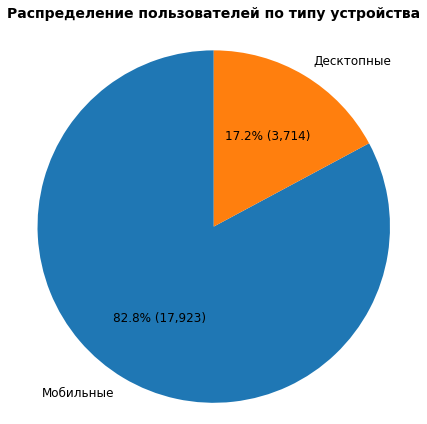

In [154]:
labels = ['Мобильные', 'Десктопные']
sizes =gr_device['user_id'].values # массив для долей

# Построение диаграммы
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels, 
    autopct=lambda p: f'{p:.1f}% ({int(p * sum(sizes) / 100):,})',  # процент и количество
    startangle=90,
    textprops={'fontsize': 12}
)

plt.title('Распределение пользователей по типу устройства', fontsize=14,fontweight='bold', pad=20)
plt.axis('equal')  # Чтобы круг был круглым, а не овалом
plt.tight_layout()
plt.show()

**Выводы:** Первая покупка в 80% случаев совершается с мобильного устройства.

- Данные сгруппированные по региону проведения мероприятия из первого заказа (top-10)

In [155]:
gr_region_rm.head(10)

,1-й регион,кол-во польз.,доля польз.
23,каменевский регион,7085,32.74
60,североярская область,3767,17.41
77,широковская область,1224,5.66
45,озернинский край,675,3.12
41,малиновоярский округ,525,2.43
76,шанырский регион,500,2.31
74,травяная область,488,2.26
57,светополянский округ,457,2.11
52,речиновская область,440,2.03
78,яблоневская область,411,1.90


<Figure size 1080x720 with 0 Axes>

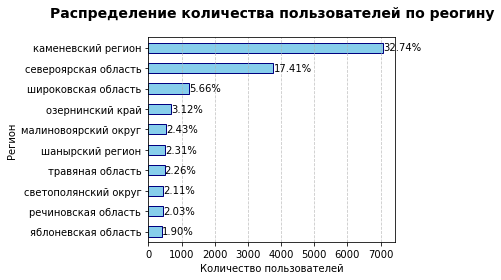

In [156]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

# Топ-10 регионов по количеству пользователей
# Сортируем по убыванию и берем первые 10
gr_region_top10 = gr_region.sort_values('user_id', ascending=False).head(10)

# Для горизонтальной диаграммы лучше сортировать по возрастанию
# (чтобы самый большой был сверху)
gr_region_top10 = gr_region_top10.sort_values('user_id', ascending=True)

# Строим горизонтальную столбчатую диаграмму
gr_region_top10.plot(
    x='first_region',        
    y='user_id',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Количество пользователей')  
plt.ylabel('Регион')                

# Добавляем значения на столбцы
for i, (_, row) in enumerate(gr_region_top10.iterrows()):
    plt.text(row['user_id'] + 5, i, f"{row['user_reg_share']:,.2f}%", 
             va='center', fontsize=10)

# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение количества пользователей по реогину', fontsize=14,fontweight='bold',pad=20)
plt.tight_layout()
plt.show()

**Выводы:** Top 3 Пользователи из каменевского района самые активные - 32%. Таксже стоит отметить пользователей из североярской области - 17%; широковская область- 5%. Остальные регионы занимают меньше 3%. 

- Данные сгруппированные по билетному оператору, продавшему билеты на первый заказ (top-5)

In [157]:
gr_service_rm.head(10)

,1-й сервис,кол-во польз.,доля польз.
3,билеты без проблем,5186,23.97
22,мой билет,2969,13.72
19,лови билет!,2809,12.98
4,билеты в руки,2559,11.83
23,облачко,2177,10.06
7,весь в билетах,1285,5.94
20,лучшие билеты,1184,5.47
24,прачечная,583,2.69
17,край билетов,454,2.10
12,дом культуры,356,1.65


<Figure size 1080x720 with 0 Axes>

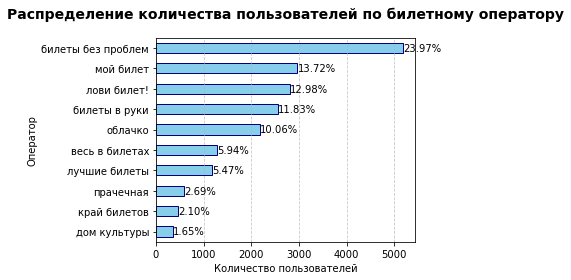

In [158]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

# Топ-10 регионов по количеству пользователей
# Сортируем по убыванию и берем первые 10
gr_service_top10 = gr_service.sort_values('user_id', ascending=False).head(10)

# Для горизонтальной диаграммы лучше сортировать по возрастанию
# (чтобы самый большой был сверху)
gr_service_top10 = gr_service_top10.sort_values('user_id', ascending=True)

# Строим горизонтальную столбчатую диаграмму
gr_service_top10.plot(
    x='first_service',        
    y='user_id',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Количество пользователей')  
plt.ylabel('Оператор')                

# Добавляем значения на столбцы
for i, (_, row) in enumerate(gr_service_top10.iterrows()):
    plt.text(row['user_id'] + 5, i, f"{row['user_serv_share']:,.2f}%", 
             va='center', fontsize=10)

# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение количества пользователей по билетному оператору', fontsize=14, fontweight='bold',pad=20)
plt.tight_layout()
plt.show()

**Выводы:** Самый популярный билетный оператор - билеты без проблем. 23,9% пользователей выбрали его для первого заказа. Далее идут мой билет - 13,7%, лови билет! - 12,9%б облачко - 10%, билеты в руки - 11,8%. Процент остальных билетных операторов менее 6%. И это с учетом, что был взят только топ 10 из 34-х представленных в БД. 

**В выделенных сегментах есть явно выраженные "точки входа" пользователей:**
- Для сегмента "мероприятия" - концерты.
- Для сегмента "устройства' - мобильные устройства. Они имеют явное преимущество по сравнению с десктопными. 
- Для сегмента "регион" - каменевский район.
- Для сегмента "билетный оператор" - билеты без проблем.

---
<a id='4.1.2'></a>
**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---

In [159]:
#мероприятие
gr_event_2 = df_user_prof99.groupby('first_event').agg(
    total_users = ('user_id', 'count'),      # всего записей в сегменте
    is_two_sum =('is_two', 'sum')            # сумма is_two
).reset_index()

# устройство
gr_device_2 = df_user_prof99.groupby('first_device').agg(
    total_users = ('user_id', 'count'),      # всего записей в сегменте
    is_two_sum =('is_two', 'sum')            # сумма is_two
).reset_index()

# регион
gr_region_2 = df_user_prof99.groupby(['first_region']).agg(
   total_users = ('user_id', 'count'),      # всего записей в сегменте
    is_two_sum =('is_two', 'sum')            # сумма is_two
).reset_index()

# сервис
gr_service_2 = df_user_prof99.groupby(['first_service']).agg(
    total_users = ('user_id', 'count'),      # всего записей в сегменте
    is_two_sum =('is_two', 'sum')            # сумма is_two
).reset_index()

# Добавляем долю внутри сегмента (вклада каждого сегмента)
gr_event_2['is_two_share'] = (gr_event_2['is_two_sum'] / gr_event_2['total_users'] * 100).round(2)
gr_device_2['is_two_share'] = (gr_device_2['is_two_sum'] / gr_device_2['total_users'] * 100).round(2)
gr_region_2['is_two_share'] = (gr_region_2['is_two_sum'] /gr_region_2['total_users'] * 100).round(2)
gr_service_2['is_two_share'] = (gr_service_2['is_two_sum'] / gr_service_2['total_users'] * 100).round(2)

# Добавляем долю от общего кол-во пользователей в сегменте
total_users_all = gr_event['user_id'].sum()
gr_event_2['is_two_allshare'] = (gr_event_2['is_two_sum'] / total_users_all * 100).round(2)
gr_device_2['is_two_allshare'] = (gr_device_2['is_two_sum'] / total_users_all * 100).round(2)
gr_region_2['is_two_allshare'] = (gr_region_2['is_two_sum'] / total_users_all * 100).round(2)
gr_service_2['is_two_allshare'] = (gr_service_2['is_two_sum'] / total_users_all * 100).round(2)

# функция для определения достоверности данных, 
# в зависимости откол-во пользователей внутри каждого сегмента
def get_reliability(total_users):
    if total_users >= 5000:
        return "Очень высокая"
    elif total_users >= 3000:
        return "Высокая"
    elif total_users >= 1000:
        return "Средняя"
    elif total_users >= 300:
        return "Низкая"
    else:
        return "Очень низкая"
    
# применяем функцию
gr_event_2['reliability'] = gr_event_2['total_users'].apply(get_reliability)
gr_device_2['reliability'] = gr_device_2['total_users'].apply(get_reliability)
gr_region_2['reliability'] = gr_region_2['total_users'].apply(get_reliability)
gr_service_2['reliability'] = gr_service_2['total_users'].apply(get_reliability)

# Сортируем
gr_event_2 = gr_event_2.sort_values('total_users', ascending=False)
gr_device_2 = gr_device_2.sort_values('total_users', ascending=False)
gr_region_2 = gr_region_2.sort_values('total_users', ascending=False)
gr_service_2 = gr_service_2.sort_values('total_users', ascending=False)

# Переименовываем столбцы
gr_event_2_rm = gr_event_2.rename(columns={
    'first_event': '1-е мероприятие',
    'total_users': 'размер сегмента', 
    'is_two_sum': 'кол-во 2+ заказов',
    'is_two_share':'доля в сегменте',
    'is_two_allshare':'доля в общ. кол-ве',
    'reliability': 'надежность'
})  

gr_device_2_rm = gr_device_2.rename(columns={
    'first_device': '1-е устр-во',
    'total_users': 'размер сегмента', 
    'is_two_sum': 'кол-во 2+ заказов',
    'is_two_share':'доля в сегменте',
    'is_two_allshare':'доля в общ. кол-ве',
    'reliability': 'надежность'
})  
gr_region_2_rm = gr_region_2.rename(columns={
    'first_region': '1-й регион',
    'total_users': 'размер сегмента', 
    'is_two_sum': 'кол-во 2+ заказов',
    'is_two_share':'доля в сегменте',
    'is_two_allshare':'доля в общ. кол-ве',
    'reliability': 'надежность'
}) 
gr_service_2_rm = gr_service_2.rename(columns={
    'first_service': '1-й сервис',
    'total_users': 'размер сегмента', 
    'is_two_sum': 'кол-во 2+ заказов',
    'is_two_share':'доля в сегменте',
    'is_two_allshare':'доля в общ. кол-ве',
    'reliability': 'надежность'
}) 


#### Для оценки надежности данных внутри сегмента, применим следующие критерии:
- если количество пользователей в выборке >= 5000: очень высокая надежность
- если количество пользователей в выборке >= 3000: высокая надежность
- если количество пользователей в выборке >= 1000: средняя надежность
- если количество пользователей в выборке >= 500:  низкая надежность
- если количество пользователей в выборке <100:    очень  низкая надежность      

- Сегмент: 'Мероприятия'

In [160]:
gr_event_2_rm

,1-е мероприятие,размер сегмента,кол-во 2+ заказов,доля в сегменте,доля в общ. кол-ве,надежность
2,концерты,9560,5911,61.83,27.32,Очень высокая
1,другое,5426,3235,59.62,14.95,Очень высокая
5,театр,4239,2687,63.39,12.42,Высокая
4,стендап,1110,676,60.90,3.12,Средняя
3,спорт,794,443,55.79,2.05,Низкая
0,выставки,414,265,64.01,1.22,Низкая
6,ёлки,95,53,55.79,0.24,Очень низкая


--------------------------------------------------
СЕГМЕНТ: МЕРОПРИЯТИЕ
--------------------------------------------------


<Figure size 1080x720 with 0 Axes>

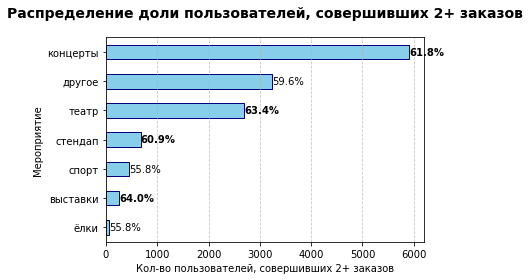

In [161]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

# сортируем для отображения на графике в порядке убывания
#gr_event_2 = gr_event_2.sort_values('is_two_share', ascending=True)
gr_event_2 = gr_event_2.sort_values('is_two_sum', ascending=True)

gr_event_2.plot(
    x='first_event',        
    y='is_two_sum',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Кол-во пользователей, совершивших 2+ заказов')  
plt.ylabel('Мероприятие')                

# Добавляем значения на столбцы 
for i, (_, row) in enumerate(gr_event_2.iterrows()):
    plt.text(row['is_two_sum'] + 5, i, f"{row['is_two_share']:,.1f}%", 
             va='center', fontsize=10, fontweight='bold'if row['is_two_share'] >=60 else 'normal')
    
print('-'*50)    
print('СЕГМЕНТ: МЕРОПРИЯТИЕ') 
print('-'*50) 

# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение доли пользователей, совершивших 2+ заказов', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

*Категории с наибольшей возвращаемостью:*
   - ТЕАТР: 63.4% (надежность: высокая, 4239 чел.)
   - КОНЦЕРТЫ: 61.8% (надежность: очень высокая, 9560 чел.) - самый массовый сегмент
   - СТЕНДАП: 60.9% (надежность: средняя, 1110 чел.) - растущий сегмент
   - ДРУГОЕ: 59.6% (надежность: очень высокая, 5426 чел.)
   
*Сегменты с низкой надежностью:*
   - ВЫСТАВКИ: 64.0% (надежность: низкая, всего 414 чел.) - данные неустойчивы
   - СПОРТ: 55,8% (надежность: низкая, 794 чел.)
   - ЁЛКИ: 55.8% (надежность: очень низкая, 95 чел.) - статистически недостоверно

- Сегмент: 'Устройства'

In [162]:
gr_device_2_rm.head()

,1-е устр-во,размер сегмента,кол-во 2+ заказов,доля в сегменте,доля в общ. кол-ве,надежность
1,mobile,17924,10900,60.81,50.37,Очень высокая
0,desktop,3714,2370,63.81,10.95,Высокая


--------------------------------------------------
СЕГМЕНТ: УСТРОЙСТВО
--------------------------------------------------


<Figure size 1080x720 with 0 Axes>

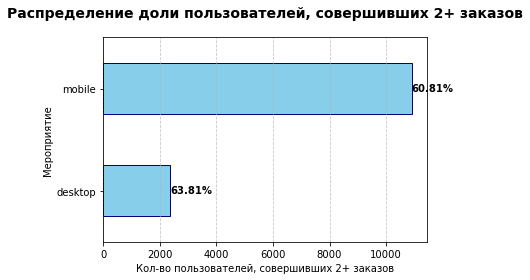

In [163]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

# сортируем для отображения на графике в порядке убывания
gr_device_2 = gr_device_2.sort_values('is_two_sum', ascending=True)

gr_device_2.plot(
    x='first_device',        
    y='is_two_sum',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Кол-во пользователей, совершивших 2+ заказов')  
plt.ylabel('Мероприятие')                

# Добавляем значения на столбцы 
for i, (_, row) in enumerate(gr_device_2.iterrows()):
    plt.text(row['is_two_sum'] + 5, i, f"{row['is_two_share']:,.2f}%", 
             va='center', fontsize=10, fontweight='bold' if row['is_two_share'] >=60 else 'normal')

print('-'*50)    
print('СЕГМЕНТ: УСТРОЙСТВО') 
print('-'*50)     
    
# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение доли пользователей, совершивших 2+ заказов', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Оба сегмента имеют хорошие показатели возвращаемости пользователей. Тем не мение по критериям надежности, мобильные устройство относятся к категории "очень высокая". В то время как декстопные устройства относятся к категории: "высокая".

- Сегмент: 'Регион' (рассмотрим топ10 регионов)

In [164]:
gr_region_2_rm.head(10)

,1-й регион,размер сегмента,кол-во 2+ заказов,доля в сегменте,доля в общ. кол-ве,надежность
23,каменевский регион,7085,4421,62.40,20.43,Очень высокая
60,североярская область,3767,2404,63.82,11.11,Высокая
77,широковская область,1224,790,64.54,3.65,Средняя
45,озернинский край,675,373,55.26,1.72,Низкая
41,малиновоярский округ,525,294,56.00,1.36,Низкая
76,шанырский регион,500,336,67.20,1.55,Низкая
74,травяная область,488,300,61.48,1.39,Низкая
57,светополянский округ,457,300,65.65,1.39,Низкая
52,речиновская область,440,279,63.41,1.29,Низкая
78,яблоневская область,411,244,59.37,1.13,Низкая


--------------------------------------------------
СЕГМЕНТ: РЕГИОН
--------------------------------------------------


<Figure size 1080x720 with 0 Axes>

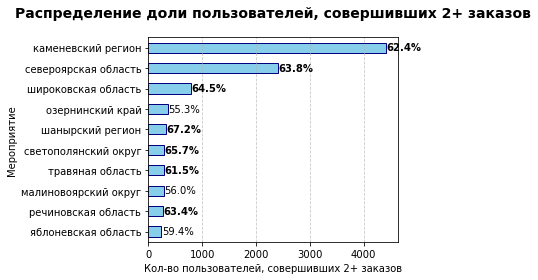

In [165]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

# Топ-10 регионов по количеству пользователей
# Сортируем по убыванию и берем первые 10
gr_region2_top10 = gr_region_2.sort_values('is_two_sum', ascending=False).head(10)

# Для горизонтальной диаграммы лучше сортировать по возрастанию
# (чтобы самый большой был сверху)
gr_region2_top10 = gr_region2_top10.sort_values('is_two_sum', ascending=True)

gr_region2_top10.plot(
    x='first_region',        
    y='is_two_sum',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Кол-во пользователей, совершивших 2+ заказов')  
plt.ylabel('Мероприятие')                

# Добавляем значения на столбцы 
for i, (_, row) in enumerate(gr_region2_top10.iterrows()):
    plt.text(row['is_two_sum'] + 5, i, f"{row['is_two_share']:,.1f}%", 
             va='center', fontsize=10, fontweight='bold'if row['is_two_share'] >=60 else 'normal')

print('-'*50)    
print('СЕГМЕНТ: РЕГИОН') 
print('-'*50)     
    
# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение доли пользователей, совершивших 2+ заказов', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

*Регионы с наибольшей возвращаемостью:*
   - североярская область: 63.8% (надежность:высокая, 3767 чел.)
   - каменевский регион: 62.4% (надежность: очень высокая, 7075 чел.) 
   - широковская область: 64.5% (надежность: средняя, 1224 чел.)

Остальные регионы хоть и имеют хороший процент возвращаемости, но надежность у них "низкая", т.к первоначальный размер сегмента не высокий.

- Сегмент: 'Билетный оператор'  (рассмотрим топ 10 операторов)

In [166]:
gr_service_2_rm.head(10)

,1-й сервис,размер сегмента,кол-во 2+ заказов,доля в сегменте,доля в общ. кол-ве,надежность
3,билеты без проблем,5186,3133,60.41,14.48,Очень высокая
22,мой билет,2969,1807,60.86,8.35,Средняя
19,лови билет!,2809,1711,60.91,7.91,Средняя
4,билеты в руки,2559,1605,62.72,7.42,Средняя
23,облачко,2177,1334,61.28,6.17,Средняя
7,весь в билетах,1285,808,62.88,3.73,Средняя
20,лучшие билеты,1184,725,61.23,3.35,Средняя
24,прачечная,583,365,62.61,1.69,Низкая
17,край билетов,454,296,65.20,1.37,Низкая
12,дом культуры,356,230,64.61,1.06,Низкая


--------------------------------------------------
СЕГМЕНТ:БИЛЕТНЫЙ ОПЕРАТОР
--------------------------------------------------


<Figure size 1080x720 with 0 Axes>

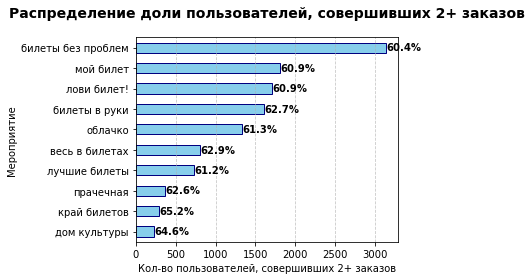

In [167]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 10))

# Топ-10 регионов по количеству пользователей
# Сортируем по убыванию и берем первые 10
gr_service2_top10 = gr_service_2.sort_values('is_two_sum', ascending=False).head(10)

# Для горизонтальной диаграммы лучше сортировать по возрастанию
# (чтобы самый большой был сверху)
gr_service2_top10 = gr_service2_top10.sort_values('is_two_sum', ascending=True)

gr_service2_top10.plot(
    x='first_service',        
    y='is_two_sum',         
    kind='barh',            # Тип графика - горизонтальная столбчатая диаграмма
    rot=0,                  # Градус вращения подписи по оси Х
    legend=False,           # Выключаем легенду
    color='skyblue',        # Добавляем цвет
    edgecolor='navy'        # Добавляем обводку
)

# Настраиваем оформление графика
plt.xlabel('Кол-во пользователей, совершивших 2+ заказов')  
plt.ylabel('Мероприятие')                

# Добавляем значения на столбцы 
for i, (_, row) in enumerate(gr_service2_top10.iterrows()):
    plt.text(row['is_two_sum'] + 5, i, f"{row['is_two_share']:,.1f}%", 
             va='center', fontsize=10, fontweight='bold'if row['is_two_share'] >=60 else 'normal')

print('-'*50)    
print('СЕГМЕНТ:БИЛЕТНЫЙ ОПЕРАТОР') 
print('-'*50)     
    
# Добавляем сетку графика
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.title('Распределение доли пользователей, совершивших 2+ заказов', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Топ 10 билетных операторов имеют высокие показатели возвращаемости пользователей во всех категориях. Но будем руководствоваться критериями оценки надежности возвращения.
- билеты без проблем: 60.4% (надежность:высокая, 5186 чел.)
- 7 операторов имеют среднюю надежность 
- 3 оператора относятся к низкой надежности

**Задача 4.1.2.** Проанализируйте возвраты пользователей:<a id='4.1.2'></a>

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

**Выводы:** 

*Сегмент: мероприятия*
- Театр, концерты, другое и стендап являются наиболее эффективными точками входа на платформу. Эти категории не только привлекают много пользователей, но и лучше всего их удерживают.
- Выставки показывают наилучший результат (64.0%), но из-за небольшого размера сегмента этот показатель может быть неустойчивым.
- Спорт находится на уровне средних значений, но имеет потенциал для роста.
- Ёлки - сезонный сегмент с недостаточными данными для надежных выводов. 

*Сегмент: устройства*
- Главный канал привлечения пользователей - это мобильные устройства. Декстопные устройства - это "качественная ниша", ее следует развивать.

*Сегмент: регион*

Основная аудитория сосредоточена в 3-х регионах.
- североярская область: 63.8% (надежность:высокая)
- каменевский регион: 62.4% (надежность: очень высокая)
- широковская область: 64.5% (надежность: средняя)

Каменевский регион - крупнейший, но возвращаемость чуть хуже, чем в широковской области. На эти регионы слеует обратить пристальное внимание, для их дальнейшего расширения. Аудиторию других регион имеет смысл расширять, там хороший потенциал.

*Сегмент: билетный оператор*
- 61.3% - это порог для определения успешных точек входа. Любой надежный сегмент с показателем выше этого значения является  эффективной точкой входа.

---
<a id='4.1.3'></a>
**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Проверим гипотезы**



Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

In [168]:
gr_event_2_rm

,1-е мероприятие,размер сегмента,кол-во 2+ заказов,доля в сегменте,доля в общ. кол-ве,надежность
2,концерты,9560,5911,61.83,27.32,Очень высокая
1,другое,5426,3235,59.62,14.95,Очень высокая
5,театр,4239,2687,63.39,12.42,Высокая
4,стендап,1110,676,60.90,3.12,Средняя
3,спорт,794,443,55.79,2.05,Низкая
0,выставки,414,265,64.01,1.22,Низкая
6,ёлки,95,53,55.79,0.24,Очень низкая


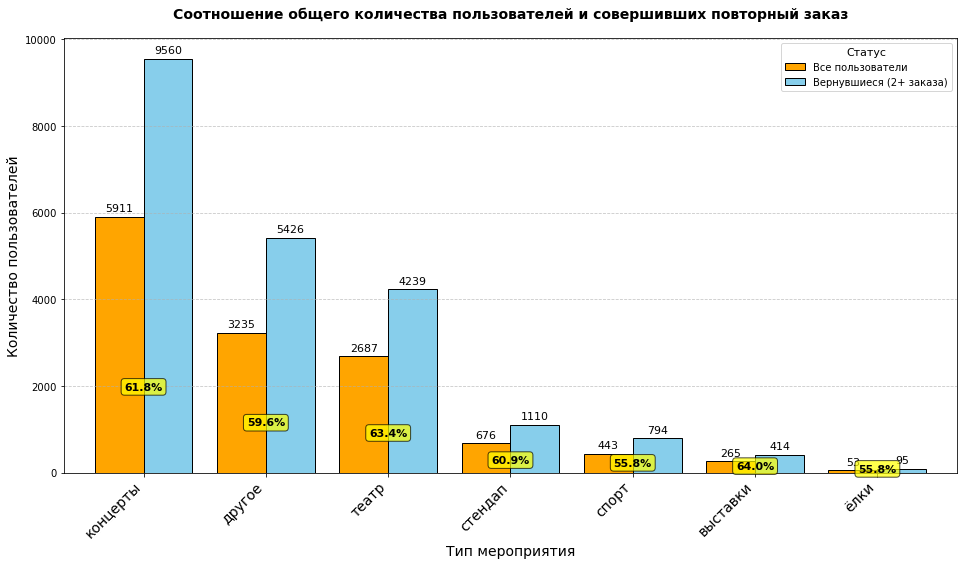

In [169]:
gr_event_2_sorted = gr_event_2.sort_values('total_users', ascending=False).reset_index(drop=True)
# Строим столбчатую диаграмму
ax = gr_event_2_sorted.plot(kind='bar', 
                            x='first_event', 
                            y=['is_two_sum', 'total_users'], 
                            figsize=(16, 8),
                            color=['orange', 'skyblue'], 
                            edgecolor='black', 
                            linewidth=1, 
                            width=0.8)

# Настраиваем график
plt.title('Соотношение общего количества пользователей и совершивших повторный заказ', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Количество пользователей', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)  
plt.legend(title='Статус', labels=['Все пользователи', 'Вернувшиеся (2+ заказа)'], 
           fontsize=10, title_fontsize=11)

# Добавляем значения над столбцами
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=3)
    
# Добавляем процент вернувшихся ВНИЗУ столбцов
for i, row in gr_event_2_sorted.iterrows():
    return_rate = (row['is_two_sum'] / row['total_users'] * 100)
     
# Размещаем внизу столбца
    ax.text(i, row['total_users'] * 0.2,  # 10% от высоты
            f'{return_rate:.1f}%', ha='center', fontsize=11, fontweight='bold',
            color='black',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
 
# Добавляем сетку для лучшей читаемости
plt.grid(axis='y', alpha=0.7, linestyle='--')

# Отображаем график
plt.show()

Тип мероприятия влияет на вероятность возврата. Пользователи, которые совершили первый заказ на спортивные мероприятия (доля возврата 55,8%), совершают повторный заказ РЕЖЕ, чем пользователи, оформившие свой первый заказ на концерты (доля возврата 61,8%). К сожалению, гипотеза НЕ подтвердилась.

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [170]:
gr_region_2_rm.head(10)

,1-й регион,размер сегмента,кол-во 2+ заказов,доля в сегменте,доля в общ. кол-ве,надежность
23,каменевский регион,7085,4421,62.40,20.43,Очень высокая
60,североярская область,3767,2404,63.82,11.11,Высокая
77,широковская область,1224,790,64.54,3.65,Средняя
45,озернинский край,675,373,55.26,1.72,Низкая
41,малиновоярский округ,525,294,56.00,1.36,Низкая
76,шанырский регион,500,336,67.20,1.55,Низкая
74,травяная область,488,300,61.48,1.39,Низкая
57,светополянский округ,457,300,65.65,1.39,Низкая
52,речиновская область,440,279,63.41,1.29,Низкая
78,яблоневская область,411,244,59.37,1.13,Низкая


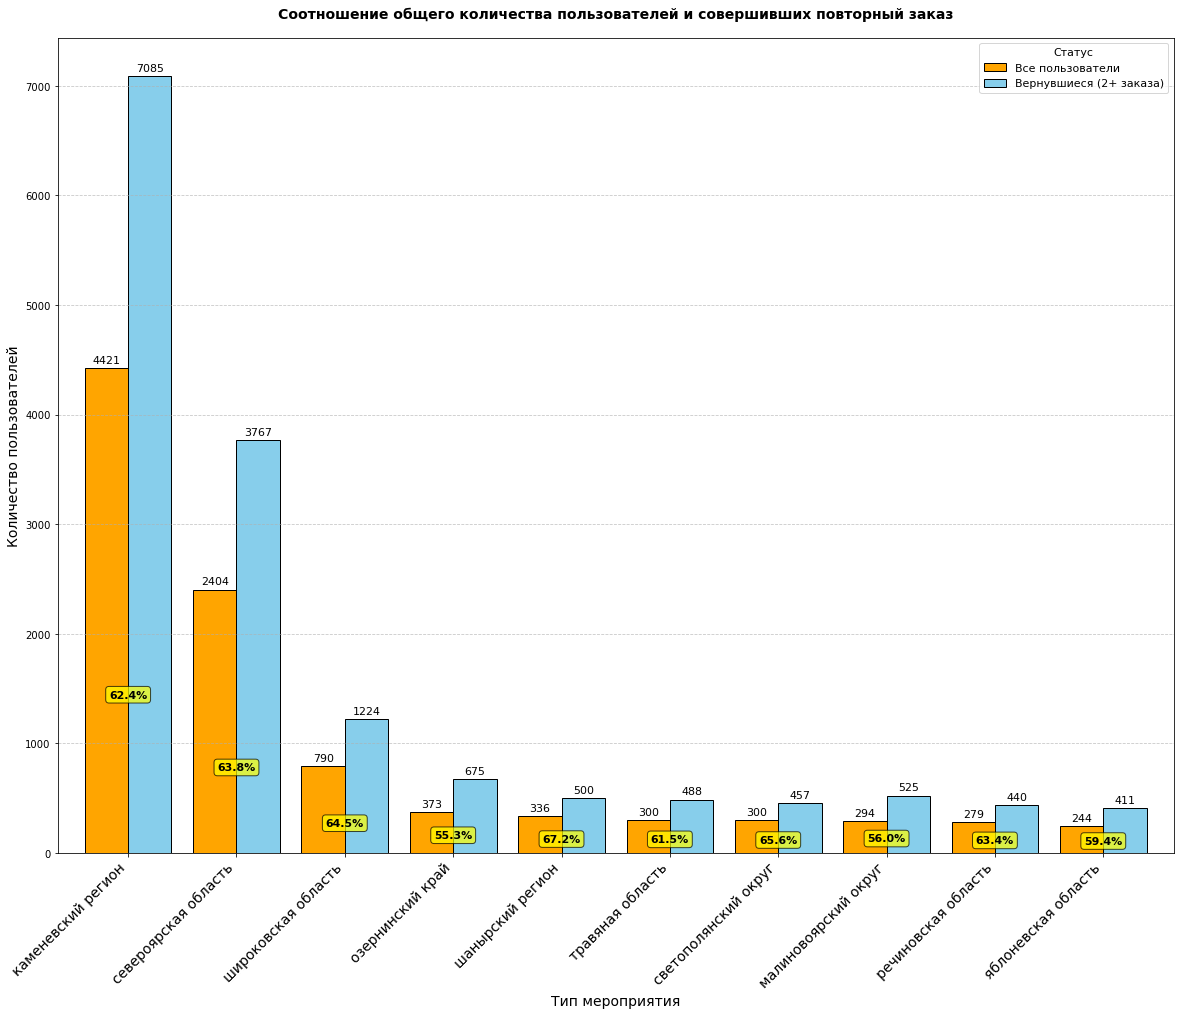

In [171]:
gr_region2_top5 = gr_region_2.sort_values('is_two_sum', ascending=False).reset_index(drop=True).head(10)

# Строим столбчатую диаграмму
ax = gr_region2_top5.plot(kind='bar', 
                          x='first_region', 
                          y=['is_two_sum', 'total_users'], 
                          figsize=(20, 15), 
                          color=['orange', 'skyblue'], 
                          edgecolor='black', 
                          linewidth=1,
                          width=0.8)

# Настраиваем график
plt.title('Соотношение общего количества пользователей и совершивших повторный заказ', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Количество пользователей', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)  
plt.legend(title='Статус', labels=['Все пользователи', 'Вернувшиеся (2+ заказа)'], 
           fontsize=11, title_fontsize=11)

# Добавляем значения над столбцами
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=3)

# Добавляем сетку для лучшей читаемости
plt.grid(axis='y', alpha=0.7, linestyle='--')

# Добавляем процент вернувшихся ВНИЗУ столбцов
for i, row in gr_region2_top5.iterrows():
    return_rate = (row['is_two_sum'] / row['total_users'] * 100)
    # Размещаем внизу столбца
    ax.text(i, row['total_users'] * 0.2,  # 10% от высоты
            f'{return_rate:.1f}%', ha='center', fontsize=11, fontweight='bold',
            color='black',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Отображаем график
plt.show()

Есть топ 3 региона, где действительно, чем больше пользователей посещают мероприяти,тем выше доля повторных заказов. Но также есть регионы с более высокой долей повторных заказов, например шанырский регион. Там доля возвратов 67,2%; светополянский округ - 65,6%. Но надежность этих данных низкая, т.к размер сегмента невелик. Гипотеза НЕ подствердилась.

---
<a id='4.2'></a>
#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---
<a id='4.2.1'></a>
**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [172]:
# Разделяем пользователей на группы
df_is_two_0 = df_user_prof99[df_user_prof99['is_two'] == 0]['avg_revenue'].dropna() #1 заказ
df_is_two_1 = df_user_prof99[df_user_prof99['is_two'] == 1]['avg_revenue'].dropna() #2+ заказ

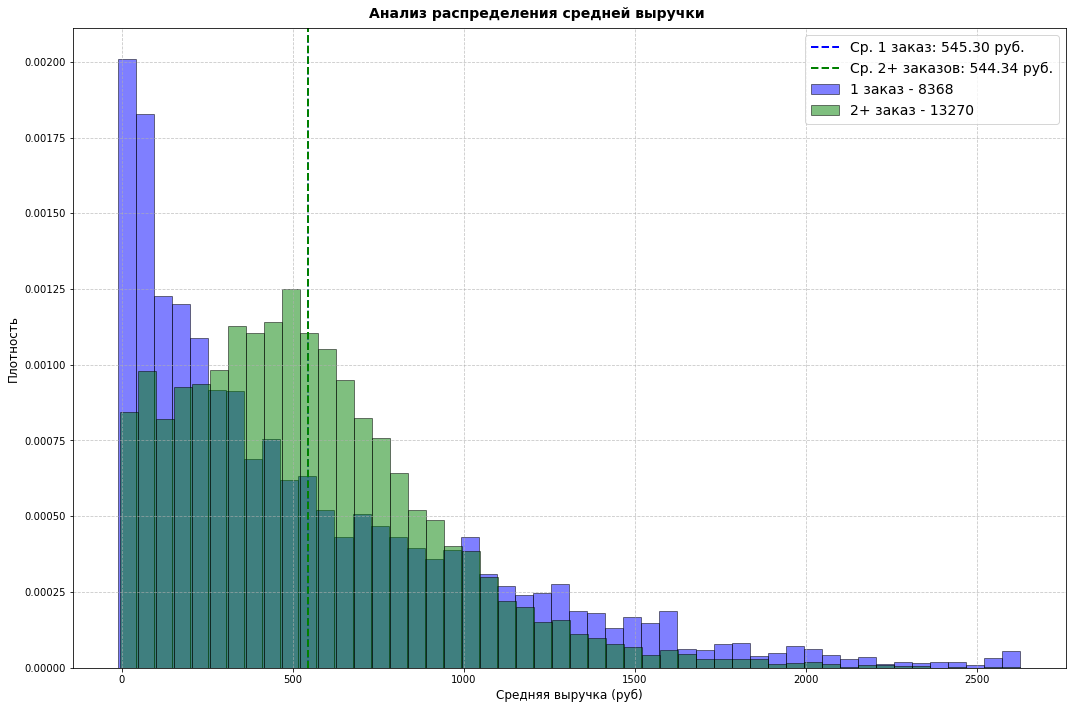

In [173]:
# Создаем фигуру и оси 
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Анализ распределения средней выручки', fontsize=14, fontweight='bold')

# Строим гистограммы
ax.hist(df_is_two_0, bins=50, alpha=0.5, label= f"1 заказ - {len(df_is_two_0)}", 
        color='blue', edgecolor='black', density=True)
ax.hist(df_is_two_1, bins=50, alpha=0.5, label= f"2+ заказ - {len(df_is_two_1)}", 
        color='green', edgecolor='black', density=True)

# Средние значения
ax.axvline(np.mean(df_is_two_0), color='blue', linestyle='--', linewidth=2,
           label=f'Ср. 1 заказ: {np.mean(df_is_two_0):.2f} руб.')
ax.axvline(np.mean(df_is_two_1), color='green', linestyle='--', linewidth=2, 
           label=f'Ср. 2+ заказов: {np.mean(df_is_two_1):.2f} руб.')

# Настройка графика
ax.set_xlabel('Средняя выручка (руб)', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Гистограмма распределения средней выручки для 1 заказа имеет правоскошенное распределение (типично для "случайных" покупок), гистограмма средней выручки 2+ заказов имеет распределение ближе к нормальному (признак сформировавшейся аудитории). Несмотря на разную форму распределений, средние значения стоимости 1 билета практически одинаковы. Это скорее всего означает, что:
- В группе 1 заказа среднее "вытягивается" за счет небольшой группы с очень высокими чеками (правый хвост)
- В группе 2+ заказов среднее формируется за счет более равномерного распределения основной массы пользователей

---
<a id='4.2.2'></a>
**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---

Посмотрим распределение на гистограмме

In [174]:
# Создаем группы
df_2_4 = df_user_prof99[(df_user_prof99['is_two'] == 1) & (df_user_prof99['is_five'] == 0)]['avg_revenue'].dropna()
df_5_plus = df_user_prof99[df_user_prof99['is_five'] == 1]['avg_revenue'].dropna()

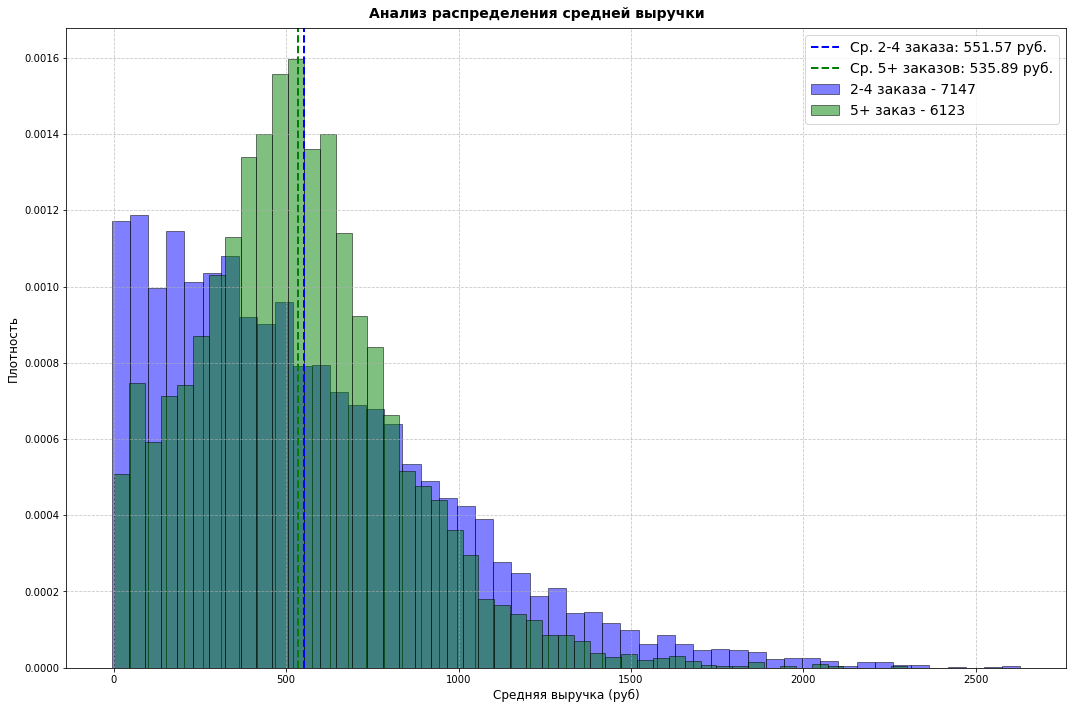

In [175]:
# Создаем фигуру и оси 
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Анализ распределения средней выручки', fontsize=14, fontweight='bold')

# Строим гистограммы
ax.hist(df_2_4, bins=50, alpha=0.5, label= f"2-4 заказа - {len(df_2_4)}", 
        color='blue', edgecolor='black', density=True)
ax.hist(df_5_plus, bins=50, alpha=0.5, label= f"5+ заказ - {len(df_5_plus)}", 
        color='green', edgecolor='black', density=True)

# Средние значения
ax.axvline(np.mean(df_2_4), color='blue', linestyle='--', linewidth=2,
           label=f'Ср. 2-4 заказа: {np.mean(df_2_4):.2f} руб.')
ax.axvline(np.mean(df_5_plus), color='green', linestyle='--', linewidth=2, 
           label=f'Ср. 5+ заказов: {np.mean(df_5_plus):.2f} руб.')

# Настройка графика
ax.set_xlabel('Средняя выручка (руб)', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Гистограмма распределения средней выручки для 2-4 заказов имеет правоскошенное распределение,в то время как гистограмма средней выручки 5+ заказов имеет распределение ближе к нормальному. Среднии значения стоимости 1 билета различаются незначительно (на 15,68 руб), причем выше среднее значение стоимости билета у заказов 2-4. Таким образом, можно сказать, что пользователи 5+ НЕ ОТЛИЧАЮТСЯ по сумме чека, а значит главный фактор лояльности - частота, а не сумма покупок. Группа пользователей 5+ имеют более стабильное и предсказуемое поведение.

---
<a id='4.2.3'></a>
**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [176]:
df_user_prof99['avg_tickets'].describe()

count    21638.000000
mean         2.743327
std          0.917496
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: avg_tickets, dtype: float64

In [177]:
print("АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА БИЛЕТОВ НА ПОВТОРНЫЕ ПОКУПКИ\n")
print("-"*70)
# Проверяем наличие данных
print(f"Всего пользователей: {len(df_user_prof99):}")
print(f"Среднее количество билетов: {df_user_prof99['avg_tickets'].mean():.2f}")
print(f"Медианное количество билетов: {df_user_prof99['avg_tickets'].median():.2f}")
print(f"Минимальное количество: {df_user_prof99['avg_tickets'].min()}")
print(f"Максимальное количество: {df_user_prof99['avg_tickets'].max()}")
print(f"Стандартное отклонение: {df_user_prof99['avg_tickets'].std():.2f}")

АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА БИЛЕТОВ НА ПОВТОРНЫЕ ПОКУПКИ

----------------------------------------------------------------------
Всего пользователей: 21638
Среднее количество билетов: 2.74
Медианное количество билетов: 2.75
Минимальное количество: 1.0
Максимальное количество: 11.0
Стандартное отклонение: 0.92


Данных для анализа: 21638


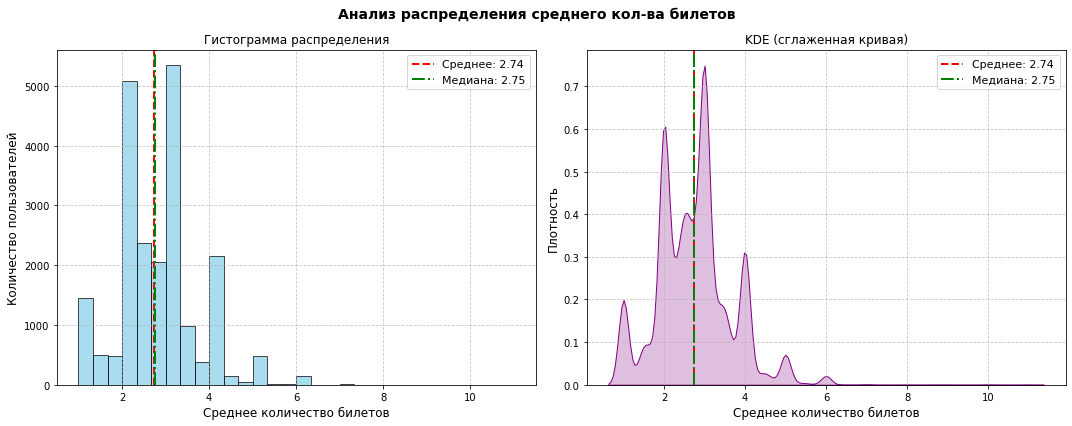

In [178]:
# Создаем фигуру и оси 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  
fig.suptitle('Анализ распределения среднего кол-ва билетов', fontsize=14, fontweight='bold')

# Подготавливаем данные
df_user_prof99_clean = df_user_prof99.copy()
df_user_prof99_clean['avg_tickets'] = pd.to_numeric(df_user_prof99_clean['avg_tickets'], errors='coerce')
df_user_prof99_clean = df_user_prof99_clean.replace([np.inf, -np.inf], np.nan)
df_user_prof99_clean = df_user_prof99_clean.dropna(subset=['avg_tickets'])

# Получаем оси для удобства
ax1 = axes[0]  # первый график
ax2 = axes[1]  # второй график

# Подготавливаем данные
df_kde_ready = df_user_prof99_clean.copy()
if 'avg_tickets' in df_kde_ready.columns:
    # Заменяем inf на NaN и удаляем NaN
    df_kde_ready['avg_tickets'] = df_kde_ready['avg_tickets'].replace([np.inf, -np.inf], np.nan)
    data_segments = df_kde_ready['avg_tickets'].dropna()
else:
    print("Колонка 'avg_tickets' не найдена!")
    data_segments = pd.Series([])

print(f"Данных для анализа: {len(data_segments)}")

# 1. Гистограмма распределения
if len(data_segments) > 0:
    ax1.hist(data_segments, bins=30, alpha=0.7, 
             color='skyblue', edgecolor='black', density=False)
    ax1.set_xlabel('Среднее количество билетов', fontsize=12)
    ax1.set_ylabel('Количество пользователей', fontsize=12)
    ax1.set_title('Гистограмма распределения')
    ax1.grid(True, alpha=0.7, linestyle='--')

    # Добавляем среднее и медиану на гистограмму
    mean_val = data_segments.mean()
    median_val = data_segments.median()
    
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f"Среднее: {mean_val:.2f}")
    ax1.axvline(median_val, color='green', linestyle='-.', linewidth=2,
                label=f"Медиана: {median_val:.2f}")
    ax1.legend(fontsize=11)

# 2. KDE график 
if len(data_segments) > 0:
    # Рисуем KDE
    sns.kdeplot(data=data_segments, fill=True, color='purple', ax=ax2)
    
    # Добавляем среднее и медиану на KDE
    ax2.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f"Среднее: {mean_val:.2f}")
    ax2.axvline(median_val, color='green', linestyle='-.', linewidth=2,
                label=f"Медиана: {median_val:.2f}")
    
    # Настройка графика
    ax2.set_xlabel('Среднее количество билетов', fontsize=12)
    ax2.set_ylabel('Плотность', fontsize=12)
    ax2.set_title('KDE (сглаженная кривая)')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.7, linestyle='--')

plt.tight_layout()
plt.show()

 - Среднее (2.74) и медиана (2.75) практически совпадают. Распределение симметричное
 - Форма распределения: правосторонняя (Большинство покупает 2-3 билета, но есть группа с 4-5+)
 - Высокая концентрация вокруг среднего значения

Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
   - от 1 до 2 билетов;
   - от 2 до 3 билетов;
   - от 3 до 5 билетов;
   - от 5 и более билетов.
    
Посмотрим на распределение по сегментам

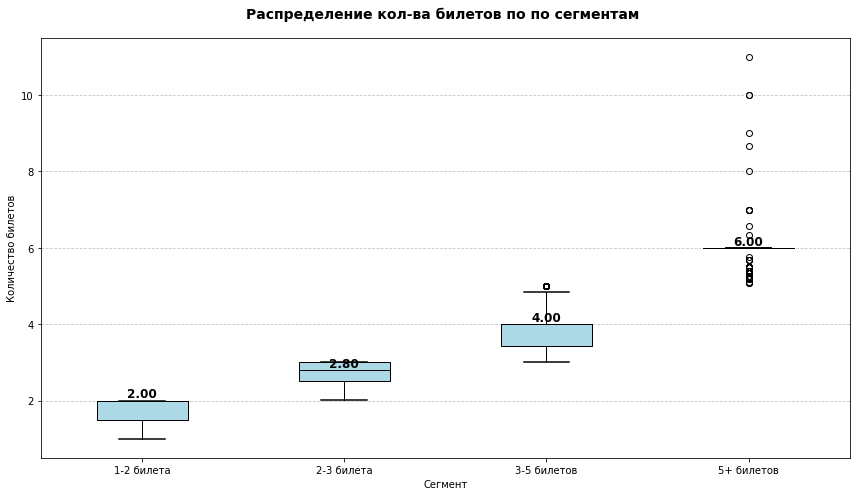

In [179]:
# Подготавливаем данные
data_segments = df_user_prof99_clean['avg_tickets'].replace([np.inf, -np.inf], np.nan).dropna()

# Строим  boxplot
fig, ax = plt.subplots(figsize=(12, 7)) 

# Box plot с распределением по сегментам
box_data = [data_segments[data_segments <= 2], 
            data_segments[(data_segments > 2) & (data_segments <= 3)],
            data_segments[(data_segments > 3) & (data_segments <= 5)],
            data_segments[data_segments > 5]]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

# Boxplot
bp = ax.boxplot(box_data, 
                labels=labels, 
                patch_artist=True,
                showfliers=True,
                boxprops={'color': 'black', 'linewidth': 1, 'facecolor': 'lightblue'},
                medianprops={'color': 'black', 'linewidth': 1},
                capprops={'color': 'black', 'linewidth': 1.5}          
               )       

# Подписываем значения медиан
for i, line in enumerate(bp['medians']):
    # Получаем координаты медианы
    x = line.get_xdata()[0] + (line.get_xdata()[1] - line.get_xdata()[0])/2
    y = line.get_ydata()[0]    
# Добавляем текст
    ax.text(x, y, f'{y:.2f}', 
            ha='center', va='bottom', 
            fontsize=12, fontweight='bold')
    
#подписываем заголовки
ax.set_title('Распределение кол-ва билетов по по сегментам ', 
             fontsize=14, pad=20, fontweight='bold')
ax.set_ylabel('Количество билетов')
ax.set_xlabel('Сегмент')
ax.grid(axis='y', alpha=0.75, linestyle='--')

plt.tight_layout()
plt.show()

Большинство покупает 2-3 билета, в группе 5+ имеются множественные выбросы.

In [180]:
# Создаем сегменты
bins2 = [0, 2, 3, 5, float('inf')]
labels2 = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

df_segments = df_user_prof99.copy()
df_segments['ticket_segment'] = pd.cut(df_segments['avg_tickets'], 
                                          bins=bins2, labels=labels2, 
                                          right=True)  # включаем правую границу

# Анализ по сегментам
df_segments = df_segments.groupby('ticket_segment', observed=False).agg(user_count=('user_id', 'count'))
                                                        
df_segments.columns = ['total_users']  
# Расчет доли пользователей
df_segments['users_share'] = (df_segments['total_users'] / 
                              df_segments['total_users'].sum() * 100).round(1)
df_segments_rm = df_segments.rename(columns={
    'total_users': 'кол-во польз.',
    'users_share': 'доля польз.'
}) 

print("\n=== СЕГМЕНТАЦИЯ ПО КОЛИЧЕСТВУ БИЛЕТОВ ===\n")
print(df_segments_rm.to_string())
print()


=== СЕГМЕНТАЦИЯ ПО КОЛИЧЕСТВУ БИЛЕТОВ ===

                кол-во польз.  доля польз.
ticket_segment                            
1-2 билета               6160         28.5
2-3 билета               9935         45.9
3-5 билетов              5349         24.7
5+ билетов                194          0.9



**Сегментация по кол-ву билетов:**
   - 1-2 билета: 28.5%
   - 2-3 билета: 45.9%
   - 3-5 билетов: 24.7%
   - 5+ билетов: 0.9%  
   
   
   В сегментах (1-2) и (3-5) равномерное распределение. Сегмент 5+ имеет аномально низкую долю средних покупок. Основной сегмент: 2-3 билета (45.9% пользователей). Преобладают покупки для компании (2-3 человека)  

**ВЫВОДЫ:**
  - Для большинства пользователей характерно приобретение 2-3 билетов,
    что указывает на покупки для компании (пара, друзья, семья)
     
  - Сегмент 1-2 билета - одиночные посетители или пары
     
  - Сегмент 3-5 билетов - семейные/групповые выходы
     
  - Сегмент 5+ билетов - организованные группы (возможно, корпоративные)

---
<a id='4.3'></a>
#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---
<a id='4.3.1'></a>
**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


#### Изучим временные параметры, связанные с первым заказом пользователей

Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей

In [181]:
# делаем копию
df_weekday = df_user_prof99.copy()

# вычисляем день недели из даты первого заказа
df_weekday['weekday'] = df_weekday['first_order_date'].dt.weekday  # 0-6
#df_weekday['weekday_name'] = df_weekday['first_order_date'].dt.day_name()

# Для русских названий
weekday_map_ru = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт',
    4: 'Пт', 5: 'Сб', 6: 'Вс'
}
df_weekday['weekday_ru'] = df_weekday['weekday'].map(weekday_map_ru)

# Группируем пользователей по дням недели первой покупки
weekday_stats = df_weekday.groupby(['weekday','weekday_ru']).agg({
    'user_id': 'count',
    'is_two': ['sum']
  #  ,'is_five': ['sum']
}).round(3).reset_index()

#weekday_stats.columns = ['weekday','weekday_ru', 'total_users', 'is_two_sum', 'is_five_sum']
weekday_stats.columns = ['weekday','weekday_ru', 'total_users', 'is_two_sum']

# Преобразуем в проценты
total_users_all = weekday_stats['total_users'].sum()
weekday_stats['total_users_share'] = (weekday_stats['total_users'] / total_users_all * 100).round(1)
weekday_stats['is_two_share'] = (weekday_stats['is_two_sum'] / weekday_stats['total_users'] * 100).round(1)
#weekday_stats['is_five_share'] = (weekday_stats['is_five_sum'] / weekday_stats['total_users'] * 100).round(1)

# Сортируем по дню недели
weekday_stats = weekday_stats.sort_index()

print("\n=== СТАТИСТИКА ПО ДНЯМ НЕДЕЛИ ===\n")
weekday_stats


=== СТАТИСТИКА ПО ДНЯМ НЕДЕЛИ ===



,weekday,weekday_ru,total_users,is_two_sum,total_users_share,is_two_share
0,0,Пн,2930,1847,13.5,63.0
1,1,Вт,3176,1966,14.7,61.9
2,2,Ср,3057,1901,14.1,62.2
3,3,Чт,3113,1850,14.4,59.4
4,4,Пт,3259,1950,15.1,59.8
5,5,Сб,3326,2089,15.4,62.8
6,6,Вс,2777,1667,12.8,60.0


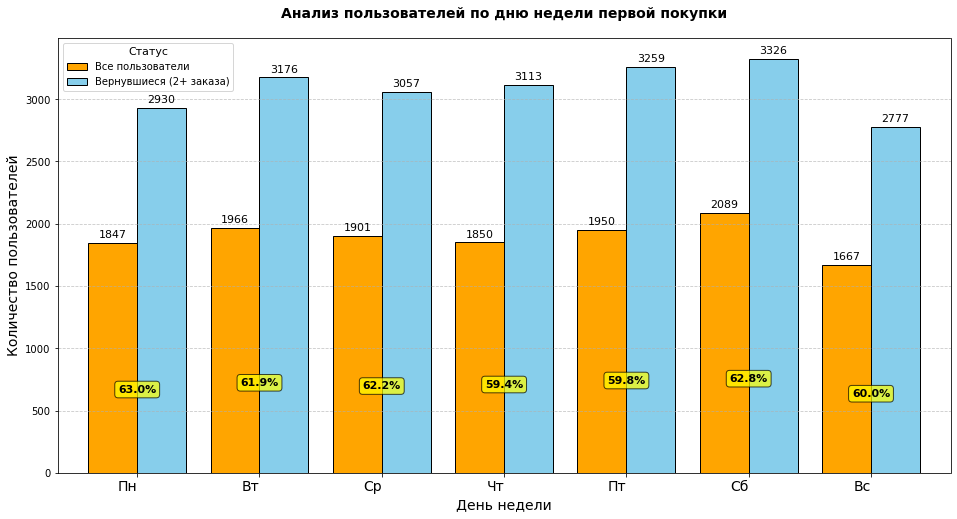

In [182]:
# Строим столбчатую диаграмму
ax = weekday_stats.plot(kind='bar', 
                        x='weekday_ru', 
                        y=['is_two_sum', 'total_users'], 
                        figsize=(16, 8),
                        color=['orange', 'skyblue'], 
                        edgecolor='black', 
                        linewidth=1, 
                        width=0.8)

# Настраиваем график
plt.title('Анализ пользователей по дню недели первой покупки', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Количество пользователей', fontsize=14)
plt.xlabel('День недели', fontsize=14)
plt.xticks(rotation=0, ha='right', fontsize=14)  
plt.legend(title='Статус', labels=['Все пользователи', 'Вернувшиеся (2+ заказа)'], 
           fontsize=10, title_fontsize=11)

# Добавляем значения над столбцами
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, padding=3)
    
# Добавляем процент вернувшихся ВНИЗУ столбцов
for i, row in weekday_stats.iterrows():
    return_rate = (row['is_two_sum'] / row['total_users'] * 100)
     
# Размещаем внизу столбца
    ax.text(i, row['total_users'] * 0.22,  # 10% от высоты
            f'{return_rate:.1f}%', ha='center', fontsize=11, fontweight='bold',
            color='black',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Добавляем сетку для лучшей читаемости
plt.grid(axis='y', alpha=0.7, linestyle='--')

# Отображаем график
plt.show()

   - Самый популярный день: Сб (3,326 чел.)
   - Самый непопулярный день: Вс (2,777 чел.)

   - Лучший день для возвратов: Пн (63.0%)
   - Худший день для возвратов: Чт (59.4%)
   
   День, в который была совершена покупка незначительно влияет на вероятность возврата пользователей.

---
<a id='4.3.2'></a>
**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---

Изучим, как средний интервал между заказами влияет на удержание клиентов.

In [183]:
print("=== АНАЛИЗ ВЛИЯНИЯ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ ===\n")

# Проверяем наличие данных
print(f"Всего пользователей: {len(df_user_prof99):}")
print(f"Пользователей с данными об интервалах: {df_user_prof99['avg_days_between'].notna().sum():}")
print(f"Доля пользователей с интервалами: {df_user_prof99['avg_days_between'].notna().mean()*100:.2f}%\n")

# Создаем группы
df_2_4 = df_user_prof99[(df_user_prof99['is_two'] == 1) & (df_user_prof99['is_five'] == 0)].copy()
df_5_plus = df_user_prof99[df_user_prof99['is_five'] == 1].copy()

# Удаляем пропуски в интервалах
df_2_4 = df_2_4.dropna(subset=['avg_days_between'])
df_5_plus = df_5_plus.dropna(subset=['avg_days_between'])

print(f"Группа 2-4 заказа: {len(df_2_4):} пользователей с данными об интервалах")
print(f"Группа 5+ заказов: {len(df_5_plus):} пользователей с данными об интервалах")

=== АНАЛИЗ ВЛИЯНИЯ СРЕДНЕГО ИНТЕРВАЛА МЕЖДУ ЗАКАЗАМИ ===

Всего пользователей: 21638
Пользователей с данными об интервалах: 13305
Доля пользователей с интервалами: 61.49%

Группа 2-4 заказа: 7147 пользователей с данными об интервалах
Группа 5+ заказов: 6123 пользователей с данными об интервалах


Статистика по группам:

In [184]:
print("\n=== СТАТИСТИКА ПО ГРУППАМ ===\n")

# Статистика для группы 2-4 заказа
stats_2_4 = {
    'Среднее': df_2_4['avg_days_between'].mean(),
    'Медиана': df_2_4['avg_days_between'].median(),
    'Стд.отклонение': df_2_4['avg_days_between'].std(),
    'Min': df_2_4['avg_days_between'].min(),
    'Max': df_2_4['avg_days_between'].max(),
    '25%': df_2_4['avg_days_between'].quantile(0.25),
    '75%': df_2_4['avg_days_between'].quantile(0.75)
}

# Статистика для группы 5+ заказов
stats_5_plus = {
    'Среднее': df_5_plus['avg_days_between'].mean(),
    'Медиана': df_5_plus['avg_days_between'].median(),
    'Стд.отклонение': df_5_plus['avg_days_between'].std(),
    'Min': df_5_plus['avg_days_between'].min(),
    'Max': df_5_plus['avg_days_between'].max(),
    '25%': df_5_plus['avg_days_between'].quantile(0.25),
    '75%': df_5_plus['avg_days_between'].quantile(0.75)
}

# Создаем DataFrame для сравнения
comparison = pd.DataFrame({
    'Метрика': stats_2_4.keys(),
    '2-4 заказа': stats_2_4.values(),
    '5+ заказов': stats_5_plus.values()
})

print("Сравнение групп:")
print(comparison.round(1).to_string(index=False))

print(f"\nРазница в среднем: {stats_5_plus['Среднее'] - stats_2_4['Среднее']:.1f} дней")


=== СТАТИСТИКА ПО ГРУППАМ ===

Сравнение групп:
       Метрика  2-4 заказа  5+ заказов
       Среднее        21.3         9.9
       Медиана         9.0         8.1
Стд.отклонение        28.5         7.8
           Min         0.0         0.0
           Max       148.0        37.5
           25%         0.0         3.9
           75%        34.0        14.1

Разница в среднем: -11.4 дней


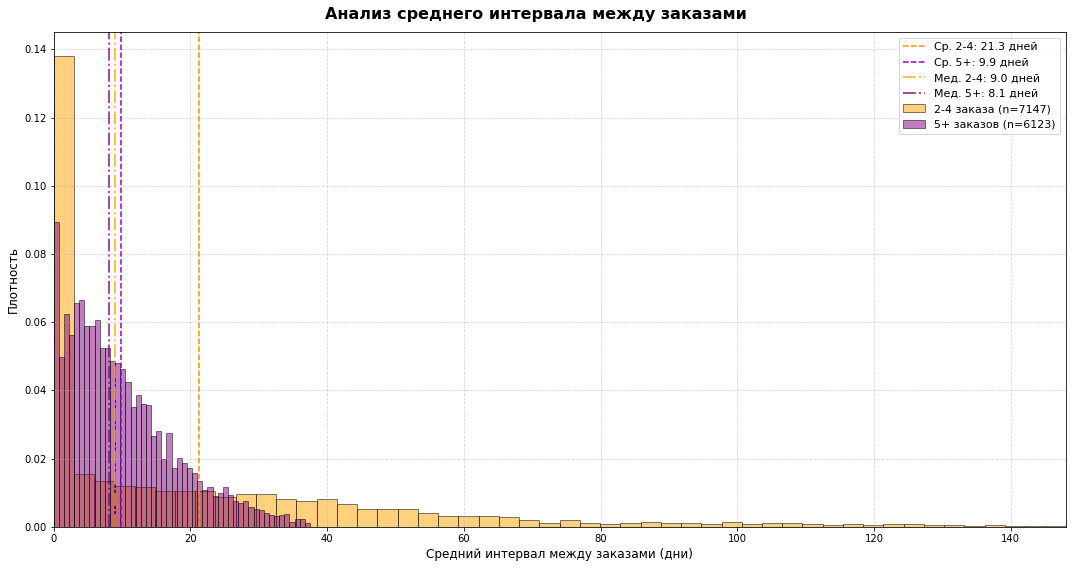

In [185]:
# Создаем фигуру и оси 
fig, ax = plt.subplots(figsize=(15, 8)) 
fig.suptitle('Анализ среднего интервала между заказами', fontsize=16, fontweight='bold')

# Удаляем пропуски (на всякий случай)
df_2_4_clean = df_2_4['avg_days_between'].dropna()
df_5_plus_clean = df_5_plus['avg_days_between'].dropna()

# Рассчитываем статистику
mean_2_4 = df_2_4_clean.mean()
mean_5_plus = df_5_plus_clean.mean()
median_2_4 = df_2_4_clean.median()
median_5_plus = df_5_plus_clean.median()

# Строим гистограммы 
ax.hist(df_2_4_clean, bins=50, alpha=0.5, label=f'2-4 заказа (n={len(df_2_4_clean)})', 
        color='orange', edgecolor='black', density=True)
ax.hist(df_5_plus_clean, bins=50, alpha=0.5, label=f'5+ заказов (n={len(df_5_plus_clean)})', 
        color='purple', edgecolor='black', density=True)

# Средние значения 
ax.axvline(mean_2_4, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'Ср. 2-4: {mean_2_4:.1f} дней')
ax.axvline(mean_5_plus, color='darkviolet', linestyle='--', linewidth=1.5, 
           label=f'Ср. 5+: {mean_5_plus:.1f} дней')

# Добавляем медианы для сравнения
ax.axvline(median_2_4, color='orange', linestyle='-.', linewidth=2, alpha=0.7,
           label=f'Мед. 2-4: {median_2_4:.1f} дней')
ax.axvline(median_5_plus, color='purple', linestyle='-.', linewidth=2, alpha=0.7,
           label=f'Мед. 5+: {median_5_plus:.1f} дней')

# Настройка графика
ax.set_xlabel('Средний интервал между заказами (дни)', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.set_xlim(0, min(200, max(df_2_4_clean.max(), df_5_plus_clean.max())))  # Ограничиваем ось X
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

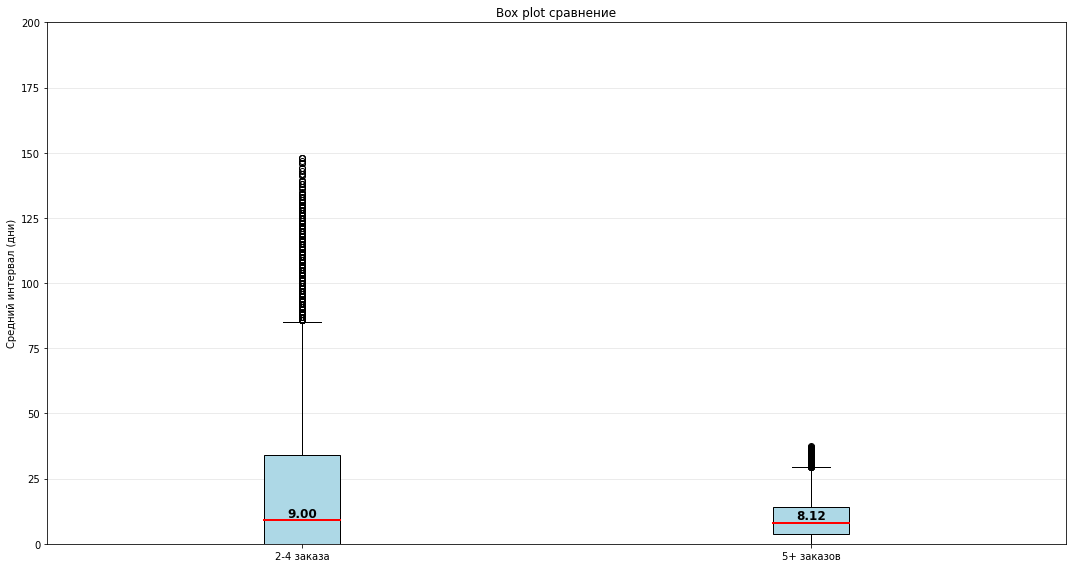

In [186]:
fig, ax = plt.subplots(figsize=(15, 8))  

#Box plot
bp = ax.boxplot([df_2_4_clean, df_5_plus_clean], 
                 labels=['2-4 заказа', '5+ заказов'],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='red', linewidth=2),
                 meanprops=dict(marker='D', markeredgecolor='black', 
                                markerfacecolor='green'))

# Подписываем значения медиан
for i, line in enumerate(bp['medians']):
    # Получаем координаты медианы
    x = line.get_xdata()[0] + (line.get_xdata()[1] - line.get_xdata()[0])/2
    y = line.get_ydata()[0]    
# Добавляем текст
    ax.text(x, y, f'{y:.2f}', 
            ha='center', va='bottom', 
            fontsize=12, fontweight='bold')
    
ax.set_ylabel('Средний интервал (дни)')
ax.set_title('Box plot сравнение')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 200)

plt.tight_layout()
plt.show()

- Доля пользователей с интервалами: 61.49%. 
- Группа 2-4 заказа: 7147 пользователей с данными об интервалах
- Группа 5+ заказов: 6123 пользователей с данными об интервалах

Группы достаточно сбалансированы по размеру, что позволяет делать корректные сравнения.Тем не менее у У 38.51% пользователей данные отсутствуют, т.к у пользователей с 1 заказом нет интервала для расчета.

**Выводы:**
- Средний интервал для группы 2-4 заказа: 21.3 дней
- Средний интервал для группы 5+ заказов: 9.9 дней
- Разница: 11.4 дней
- Группа с 5+ заказами совершает покупки примерно на 50% чаще

ВЛИЯНИЕ ИНТЕРВАЛА НА ВЕРОЯТНОСТЬ ПОВТОРНЫХ ЗАКАЗОВ: чем чаще покупают (меньше интервал), тем выше вероятность стать постоянным клиентом и попасть в группу 5+, т.к лояльные клиенты (5+ заказов) имеют меньший интервал между покупками. Клиенты с интервалом меньше 10 дней имеют наибольшую вероятность стать постоянными, т.к чем меньше интервал, тем больше заказов. 

---
<a id='4.4'></a>
#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---
<a id='4.4.1'></a>
**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Рассчитаем коэффициент корреляции  между признаками профиля пользователя и числом заказов.

In [187]:
# Подготовка данных
df_phi = df_user_prof99[['total_orders', 'avg_revenue', 'avg_tickets', 'avg_days_between', 'is_two', 'is_five']].copy()

interval_cols = ['total_orders','avg_revenue', 'avg_tickets', 'avg_days_between']

# Рассчитываем матрицу корреляций phi_k
corr_matrix = df_phi.phik_matrix(interval_cols=interval_cols)
#смотрим корреляцию по столбцу total_oreder
corr_matrix = corr_matrix.loc[corr_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

print("МАТРИЦА КОРРЕЛЯЦИЙ PHI_K")
corr_matrix.round(3)

МАТРИЦА КОРРЕЛЯЦИЙ PHI_K


,total_orders
is_five,0.615
is_two,0.309
avg_days_between,0.284
avg_tickets,0.226
avg_revenue,0.219


Строим тепловую карту

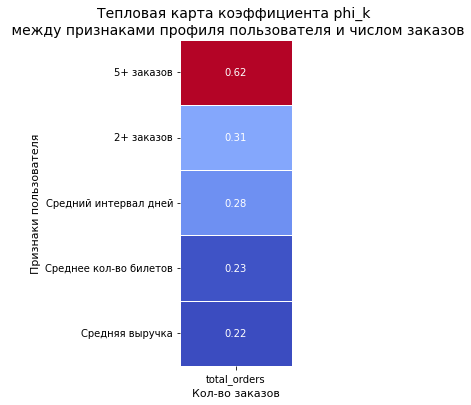

In [188]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

russian_labels = [
    '5+ заказов',
    '2+ заказов',
    'Средний интервал дней',
    'Среднее кол-во билетов', 
    'Средняя выручка'   
]

# Сохраняем матрицу корреляции признака total_orders с другими признаками клиента
data_heatmap = corr_matrix.loc[corr_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)

sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f',             cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False, # Отключаем цветовую шкалу   
            yticklabels=russian_labels  # Задаем русские подписи        
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n между признаками профиля пользователя и числом заказов', fontsize=14)
plt.xlabel('Кол-во заказов', fontsize=11)
plt.yticks(rotation=0)  # Делаем подписи оси Y тоже горизонтальными
plt.ylabel('Признаки пользователя', fontsize=11)
#plt.tight_layout()  # Автоматически подгоняет размеры
# Выводим график
plt.show()

Корелляция количества заказов со средней выручкой, со средним кол-м билетов и промежутком между заказами - средняя, ближе к низкой. Эти показатели имеют наименьшее влияние на количество заказов, поэтому ее мы в расчтет брать не будем. Наблюдается сильная связь между кол-м заказов 5+ (0.615) с общим количеством заказов. Группа 2+ (0.309) - более слабая связь, так как это промежуточная группа. Но эти клиенты - потенциал для перехода в лояльные.

### 5. Общий вывод и рекомендации <a id='5'></a>

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Информация о данных**

Предоставленные для анализа данные загрузились корректно.

  - датасет содержит 15 колонок и около 29000 записей.
  - датасет имеет размер около 33 МБ
  - данные соответствуют описанию
  - наименования стобцов имеют единый вид написания
  - типы данных используются корректные
  - имеются пропуски в столбцу days_since_prev, но это связано с тем, что для первой покупки пользователя расчитать кол-во дней от предыдущей нет возвозможности.
  - Типы данных в некоторых стобцах пришлось преобразовать и нормализовать, для удобства дальнейшей работы с ними. 

**В ходе предъобработки данных были произведены следующие действия:**
- Данные о выручке сервиса были представлены в российских рублях и казахстанских тенге. Привели выручку к единой валюте — российскому рублю.Создали дополнительное поле в БД и конвертировали данные в соотвествии с курсом тенге.
- Преобразовали типы данных в некоторых столбцах; сократили размерность некоторых числовых столбцов.
- Нормализованы значения в столбцах город и регион, а также в наименовании билетного оператора.
- проверили на пропуски и дубликаты. Дубликаты не обнаружены.Пропуски только в вновь созданном поле days_since_prev, что допустимо.
- создано 2 дополнительных столбца: revenue_rub (конвертация из тенге в рубли) и curs_n (курс тенге к рублю) Всего 17 столбцов.
- данные были отфильтрованы по 99-му прецентилю. Мы избавились таким образом от выбросов в размере 0,97% от общего объема данных

После предъобработки построили профиль пользователя, чтобы производить анализ на основе признаков профиля пользователя.
В него вошли следующие данные:

  -  дата первого и последнего заказа;
  -  устройство, с которого был сделан первый заказ;
  -  регион, в котором был сделан первый заказ;
  -  билетный партнёр, к которому обращались при первом заказе;
  -  жанр первого посещённого мероприятия;
  -  общее количество заказов;
  -  средняя выручка с одного заказа в рублях;
  -  среднее количество билетов в заказе;
  -  среднее время между заказами;
  -  бинарный признак - совершил ли пользователь 2 и более заказа;
  -  бинарный признак - совершил ли пользователь 5 и более заказов.  

## Результаты анализа

Общее число пользователей: 21854
Средняя выручка с одного заказа: 544.40 руб.
Доля пользователей с 2+ заказами: 61.71%
Доля пользователей с 5+ заказами: 29.01%

**Заказы:**
- Сильная асимметрия: среднее (13.2) намного выше медианы (2)
- Eсть покупатели с экстремальным числом билетов в заказе (max = 10181 заказов!)
- 75% пользователей сделали ≤ 5 заказов
- Лояльные пользователи (с 5+ заказами) - 29%
- Доля пользователей с 2+ заказами: 61.71%, больше половины покупателей возвращаются
- Средняя выручка с одного заказа: 544.40 руб. 
 
**Покупка билетов**
- В среднем 2.74 билета на заказ
- Медиана близка к среднему (2.75) - распределение ближе к нормальному
- Большинство покупает 2-3 билета за раз

**Частота покупок**
- 13521 пользователей (61.9%) совершают повторные покупки
- В среднем возвращаются через 2 недели (15.8 дней)
- Медианное время возврата: 8.0 дней
- 25% самых лояльных возвращаются в течение 1 дня

---

###  Распределение пользователей по признакам:

 - Исследование признаков первого заказа и их связи с возвращением на платформу
 
Самое популярное мероприятие среди пользователей - это концерты (44%), далее театр и другое (около 20%), остальные мероприятия занимают от 2 до 5%. Елки всего 0,44%, т.к это сезонное мероприятие.

 - по типу устройства, с которого совершена первая покупка;
 
Первая покупка в 80% случаев совершается с мобильного устройства. 

 - по региону проведения мероприятия из первого заказа;
 
Top 3 Пользователи из каменевского района самые активные - 32%. Таксже стоит отметить пользователей из североярской области - 17%; широковская область- 5%. Остальные регионы занимают меньше 3%.  
 
 - по билетному оператору, продавшему билеты на первый заказ
 
Самый популярный билетный оператор - билеты без проблем. 23,9% пользователей выбрали его для первого заказа. Далее идут мой билет - 13,7%, лови билет! - 12,9%б облачко - 10%, билеты в руки - 11,8%. Процент остальных билетных операторов менее 6%. И это с учетом, что был взят только топ 10 из 34-х представленных в БД. 

**В выделенных сегментах есть явно выраженные "точки входа" пользователей:**
- Для сегмента "мероприятия" - концерты.
- Для сегмента "устройства' - мобильные устройства. Они имеют явное преимущество по сравнению с десктопными. 
- Для сегмента "регион" - каменевский район.
- Для сегмента "билетный оператор" - билеты без проблем.

*Сегмент: мероприятия*
- Театр, концерты, другое и стендап являются наиболее эффективными точками входа на платформу. Эти категории не только привлекают много пользователей, но и лучше всего их удерживают.
- Выставки показывают наилучший результат (64.0%), но из-за небольшого размера сегмента этот показатель может быть неустойчивым.
- Спорт находится на уровне средних значений, но имеет потенциал для роста.
- Ёлки - сезонный сегмент с недостаточными данными для надежных выводов. 

*Сегмент: устройства*
- Главный канал привлечения пользователей - это мобильные устройства. Декстопные устройства - это "качественная ниша", ее следует развивать.

*Сегмент: регион*

Основная аудитория сосредоточена в 3-х регионах.
- североярская область: 63.8% (надежность:высокая)
- каменевский регион: 62.4% (надежность: очень высокая)
- широковская область: 64.5% (надежность: средняя)

Каменевский регион - крупнейший, но возвращаемость чуть хуже, чем в широковской области. На эти регионы слеует обратить пристальное внимание, для их дальнейшего расширения. Аудиторию других регион имеет смысл расширять, там хороший потенциал.

*Сегмент: билетный оператор*
- 61.3% - это порог для определения успешных точек входа. Любой надежный сегмент с показателем выше этого значения является  эффективной точкой входа.

---

###  Проверка гипотез
В процессе анализа возникли 2 гипотезы, которые проверим на состоятельность.

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Тип мероприятия влияет на вероятность возврата. Пользователи, которые совершили первый заказ на спортивные мероприятия (доля возврата 55,8%), совершают повторный заказ РЕЖЕ, чем пользователи, оформившие свой первый заказ на концерты (доля возврата 61,8%). К сожалению, гипотеза НЕ подтвердилась.

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

Есть топ 3 региона, где действительно, чем больше пользователей посещают мероприяти,тем выше доля повторных заказов. Но также есть регионы с более высокой долей повторных заказов, например шанырский регион. Там доля возвратов 67,2%; светополянский округ - 65,6%. Но надежность этих данных низкая, т.к размер сегмента невелик. Гипотеза НЕ подствердилась.

---

### Исследование поведения пользователей через показатели выручки и состава заказа

**связь между средней выручкой сервиса с заказа и повторными заказами.**

Средние значения стоимости 1 билета практически одинаковы. Это скорее всего означает, что:
- В группе 1 заказа среднее "вытягивается" за счет небольшой группы с очень высокими чеками (правый хвост)
- В группе 2+ заказов среднее формируется за счет более равномерного распределения основной массы пользователей

**Анализ распределения средней выручки**
Средние значения стоимости 1 билета различаются незначительно (на 15,68 руб), причем выше среднее значение стоимости билета у заказов 2-4. Таким образом, можно сказать, что пользователи 5+ НЕ ОТЛИЧАЮТСЯ по сумме чека, а значит главный фактор лояльности - частота, а не сумма покупок. Группа пользователей 5+ имеют более стабильное и предсказуемое поведение.

**Анализ влияния среднего количества билетов в заказе на вероятность повторной покупки.**
  Для большинства пользователей характерно приобретение 2-3 билетов,
   что указывает на покупки для компании (пара, друзья, семья)     
  - Сегмент 1-2 билета - одиночные посетители или пары   
  - Сегмент 3-5 билетов - семейные/групповые выходы     
  - Сегмент 5+ билетов - организованные группы (возможно, корпоративные)
  
---

### Исследование временных характеристик первого заказа и их влияния на повторные покупки

**Анализ, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей**
   - Самый популярный день: Сб (3,326 чел.)
   - Самый непопулярный день: Вс (2,777 чел.)

   - Лучший день для возвратов: Пн (63.0%)
   - Худший день для возвратов: Чт (59.4%)
   
   День, в который была совершена покупка незначительно влияет на вероятность возврата пользователей.
   
**Анализ влияния среднего интервала между заказами**  
- Доля пользователей с интервалами: 61.49%. 
- Группа 2-4 заказа: 7147 пользователей с данными об интервалах
- Группа 5+ заказов: 6123 пользователей с данными об интервалах

Группы достаточно сбалансированы по размеру, что позволяет делать корректные сравнения.Тем не менее у У 38.51% пользователей данные отсутствуют, т.к у пользователей с 1 заказом нет интервала для расчета.

- Средний интервал для группы 2-4 заказа: 21.3 дней
- Средний интервал для группы 5+ заказов: 9.9 дней
- Разница: 11.4 дней
- Группа с 5+ заказами совершает покупки примерно на 50% чаще

ВЛИЯНИЕ ИНТЕРВАЛА НА ВЕРОЯТНОСТЬ ПОВТОРНЫХ ЗАКАЗОВ: чем чаще покупают (меньше интервал), тем выше вероятность стать постоянным клиентом и попасть в группу 5+, т.к лояльные клиенты (5+ заказов) имеют меньший интервал между покупками. Клиенты с интервалом меньше 10 дней имеют наибольшую вероятность стать постоянными, т.к чем меньше интервал, тем больше заказов. 

---
### Корреляционный анализ количества покупок и признаков пользователя

Корелляция количества заказов со средней выручкой, со средним количеством билетов и промежутком между заказами - средняя, ближе к низкой. Эти показатели имеют наименьшее влияние на количество заказов. Наблюдается сильная связь между кол-м заказов 5+ (0.615) с общим количеством заказов. Группа 2+ (0.309) - более слабая связь, так как это промежуточная группа. Но эти клиенты - потенциал для перехода в лояльные.

---


### 6. Финализация проекта и публикация в Git 

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/zhnataly/tickets_afisha_2